# 5G Handover — Dataset Exploration From Scratch
## Goal: Understand EVERYTHING in the data before touching any model

We go file by file, column by column.
We ask: **what is this column, does it vary, is it useful, should we keep it?**

No modeling here. Just understanding.

---

## CELL 1 — Imports

In [84]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
BASE_PATH    = './DATASET/'
SAMPLE_SIZE  = 100_000   # rows per file — increase if you have RAM

COLORS = {
    'hbahn':  '#2ecc71',
    'mobile': '#3498db',
    'static': '#e74c3c'
}

print('✅ Imports done')

✅ Imports done


---
## CELL 2 — Load all files
We load H-Bahn, Mobile, and Static — all files, all scenarios.
Static is NOT ignored — we will explore it properly.

In [86]:
FILES = {
    'hbahn':  ['cell_data', 'neighboring_data', 'latency_data', 'iperf_data'],
    'mobile': ['cell_data', 'neighboring_data', 'latency_data', 'iperf_data'],
    'static': ['cell_data', 'latency_data', 'static_locations'],
}

raw = {}
for scenario, filelist in FILES.items():
    raw[scenario] = {}
    spath = os.path.join(BASE_PATH, scenario, scenario)
    print(f'\n📂 {scenario.upper()}')
    for fname in filelist:
        fpath = os.path.join(spath, f'{fname}.csv')
        try:
            nrows = None if fname == 'static_locations' else SAMPLE_SIZE
            df = pd.read_csv(fpath, sep=';', nrows=nrows, low_memory=False)
            raw[scenario][fname] = df
            print(f'  ✅ {fname:25s} {str(df.shape):20s} '
                  f'missing={df.isnull().mean().mean()*100:.1f}%')
        except FileNotFoundError:
            print(f'  ❌ {fname:25s} NOT FOUND')
        except Exception as e:
            print(f'  ⚠️  {fname:25s} ERROR: {e}')

print('\n✅ Loading complete')


📂 HBAHN
  ✅ cell_data                 (100000, 35)         missing=16.9%
  ✅ neighboring_data          (100000, 20)         missing=6.6%
  ✅ latency_data              (100000, 42)         missing=12.6%
  ✅ iperf_data                (71393, 46)          missing=13.1%

📂 MOBILE
  ✅ cell_data                 (100000, 33)         missing=11.9%
  ✅ neighboring_data          (100000, 23)         missing=13.0%
  ✅ latency_data              (100000, 47)         missing=10.8%
  ✅ iperf_data                (100000, 49)         missing=18.1%

📂 STATIC
  ✅ cell_data                 (100000, 37)         missing=19.1%
  ✅ latency_data              (100000, 47)         missing=22.5%
  ✅ static_locations          (4, 4)               missing=0.0%

✅ Loading complete


---
## CELL 3 — Full column audit: every file, every column

For every file we print:
- Column name
- Data type
- % missing
- Number of unique values
- Min, max, mean (for numbers)
- A sample value

**This is where we decide what is useful and what is garbage.**

In [88]:
def audit_file(df, label):
    print(f'\n{"="*70}')
    print(f'  {label}  |  {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'{"="*70}')
    
    rows = []
    for col in df.columns:
        s      = df[col]
        miss   = s.isnull().mean() * 100
        nuniq  = s.nunique()
        dtype  = str(s.dtype)
        sample = s.dropna().iloc[0] if s.dropna().shape[0] > 0 else 'ALL NULL'
        
        if pd.api.types.is_numeric_dtype(s) and s.dtype != bool:
            s_float = s.astype(float)
            mn  = round(float(s_float.min()), 3)
            mx  = round(float(s_float.max()), 3)
            avg = round(float(s_float.mean()), 3)
            info = f'min={mn}  max={mx}  mean={avg}'
        else:
            info = f'sample values: {s.dropna().unique()[:3].tolist()}'
        
        # flag columns that are likely useless
        flag = ''
        if miss == 100:             flag = '🔴 ALL MISSING — DROP'
        elif miss > 60:             flag = '🟠 HIGH MISSING'
        elif miss > 40:             flag = '🟡 MEDIUM MISSING'
        elif nuniq <= 1:            flag = '🔴 CONSTANT — DROP'
        elif nuniq <= 2:            flag = '🟡 NEAR CONSTANT'
        elif nuniq == df.shape[0]:  flag = '🔵 UNIQUE ID (likely metadata)'
        
        rows.append({
            'column':  col,
            'dtype':   dtype,
            'missing': f'{miss:.1f}%',
            'unique':  nuniq,
            'range/sample': info,
            'flag':    flag
        })
    
    result = pd.DataFrame(rows)
    print(result.to_string(index=False))
    return result


audits = {}
for scenario in raw:
    audits[scenario] = {}
    for fname, df in raw[scenario].items():
        audits[scenario][fname] = audit_file(df, f'{scenario.upper()} / {fname}')


  HBAHN / cell_data  |  100,000 rows × 35 columns
            column   dtype missing  unique                                            range/sample                 flag
         timestamp   int64    0.0%   98207 min=1683266839.0  max=1689741392.0  mean=1684416554.108                     
           network float64  100.0%       0                              min=nan  max=nan  mean=nan 🔴 ALL MISSING — DROP
        cell_index float64    1.1%      78               min=0.0  max=52617235.0  mean=26238028.53                     
   physical_cellid float64    9.7%      92                        min=3.0  max=792.0  mean=287.289                     
tracking_area_code float64   99.9%       1                     min=8958.0  max=8958.0  mean=8958.0       🟠 HIGH MISSING
            earfcn float64    9.8%      14                     min=100.0  max=9460.0  mean=1515.88                     
              rsrp float64    9.7%      66                     min=-122.0  max=-55.0  mean=-90.724           

---
## CELL 4 — Understand the timestamps

Timestamps are the key that links all files together.
We need to know: what format are they in? Can we join on them?

In [90]:
print('TIMESTAMP AUDIT')
print('='*60)

for scenario in ['hbahn', 'mobile']:
    for fname in raw[scenario]:
        df = raw[scenario][fname]
        ts_cols = [c for c in df.columns if 'time' in c.lower() or c == 'ts']
        if not ts_cols:
            continue
        print(f'\n{scenario}/{fname}:')
        for col in ts_cols:
            vals = df[col].dropna()
            if len(vals) == 0:
                print(f'  {col}: ALL NULL')
                continue
            sample = vals.iloc[0]
            # Try to understand the format
            numeric = pd.to_numeric(vals, errors='coerce')
            if numeric.notna().mean() > 0.9:
                med = numeric.median()
                if med > 1e12:
                    fmt = 'Unix MILLISECONDS'
                elif med > 1e9:
                    fmt = 'Unix SECONDS'
                else:
                    fmt = f'numeric (median={med:.0f}) — unknown unit'
            else:
                fmt = 'STRING/DATE format'
            print(f'  {col:25s}: {fmt:30s} | sample: {sample}')

TIMESTAMP AUDIT

hbahn/cell_data:
  timestamp                : Unix SECONDS                   | sample: 1689741392

hbahn/latency_data:
  timestamp                : Unix SECONDS                   | sample: 1668616436

hbahn/iperf_data:
  timestampstart           : STRING/DATE format             | sample: 2022-11-16 16:34:00.666191
  timestampend             : STRING/DATE format             | sample: 2022-11-16 16:34:03.786542
  timestamp                : Unix SECONDS                   | sample: 1668616457

mobile/cell_data:
  timestamp_day            : numeric (median=53380) — unknown unit | sample: 22648.819999933243

mobile/neighboring_data:
  timestamp_day            : numeric (median=36340) — unknown unit | sample: 21544.57699894905

mobile/latency_data:
  timestamp_day            : numeric (median=31822) — unknown unit | sample: 17937.92199921608

mobile/iperf_data:
  timestamp_day            : numeric (median=32296) — unknown unit | sample: 19223.22499895096


---
## CELL 5 — See an actual handover happen in raw data

Before building any model, let's just SEE a real handover.
A handover = `physical_cellid` changes between two consecutive rows.
Let's find one and look at the radio conditions around it.

In [92]:
print('REAL HANDOVER EVENTS IN RAW DATA')
print('='*60)

for scenario in ['hbahn', 'mobile']:
    df = raw[scenario]['cell_data'].copy()
    
    # Sort by time
    ts_col = next((c for c in ['timestamp','timestampstart'] 
                   if c in df.columns), None)
    if ts_col:
        df['ts_num'] = pd.to_numeric(df[ts_col], errors='coerce')
        df = df.sort_values('ts_num').reset_index(drop=True)
    
    if 'physical_cellid' not in df.columns:
        print(f'{scenario}: no physical_cellid'); continue
    
    # Detect handovers
    df['prev_cell'] = df['physical_cellid'].shift(1)
    df['is_ho']     = (df['physical_cellid'] != df['prev_cell']) & df['prev_cell'].notna()
    
    n_ho    = df['is_ho'].sum()
    n_cells = df['physical_cellid'].nunique()
    
    print(f'\n{scenario.upper()}:')
    print(f'  Rows loaded:       {len(df):,}')
    print(f'  Unique towers:     {n_cells}')
    print(f'  Handover events:   {n_ho}')
    print(f'  HO rate:           {n_ho/len(df)*100:.2f}% of rows')
    
    # Show what a handover looks like
    ho_indices = df[df['is_ho']].index.tolist()
    if ho_indices:
        idx = ho_indices[0]
        show_cols = [c for c in 
                     ['physical_cellid','rsrp','rsrq','sinr',
                      'cqi','ta','velocity','is_ho']
                     if c in df.columns]
        window = df.iloc[max(0, idx-4): idx+5][show_cols]
        print(f'\n  ── First handover at row {idx} ──')
        print(window.to_string())
        print()
        print('  Notice: physical_cellid changes → that is the handover moment')
        print('  Look at rsrp and sinr before and after — does quality change?')

REAL HANDOVER EVENTS IN RAW DATA

HBAHN:
  Rows loaded:       100,000
  Unique towers:     92
  Handover events:   13207
  HO rate:           13.21% of rows

  ── First handover at row 1 ──
   physical_cellid    rsrp    rsrq   sinr    cqi    ta  velocity  is_ho
0          301.000 -94.000     NaN  8.000  6.000 4.000    12.513  False
1          300.000 -81.000 -10.000 16.000 11.000 3.000    12.486   True
2          300.000 -83.000  -9.000 17.000 14.000 3.000    12.509  False
3          300.000 -83.000 -12.000 15.000  8.000 1.000    12.609  False
4          300.000 -78.000 -12.000 12.000 11.000 1.000    12.641  False
5          300.000 -79.000 -15.000 12.000 12.000 1.000    11.887  False

  Notice: physical_cellid changes → that is the handover moment
  Look at rsrp and sinr before and after — does quality change?

MOBILE:
  Rows loaded:       100,000
  Unique towers:     360
  Handover events:   4790
  HO rate:           4.79% of rows

  ── First handover at row 27 ──
    physical_cellid

---
## CELL 6 — Signal quality deep dive: every metric explained

For each radio column we:
1. Show its distribution
2. Compare H-Bahn vs Mobile vs Static
3. Show what it looks like BEFORE vs AFTER a handover
4. Decide if it's useful for prediction

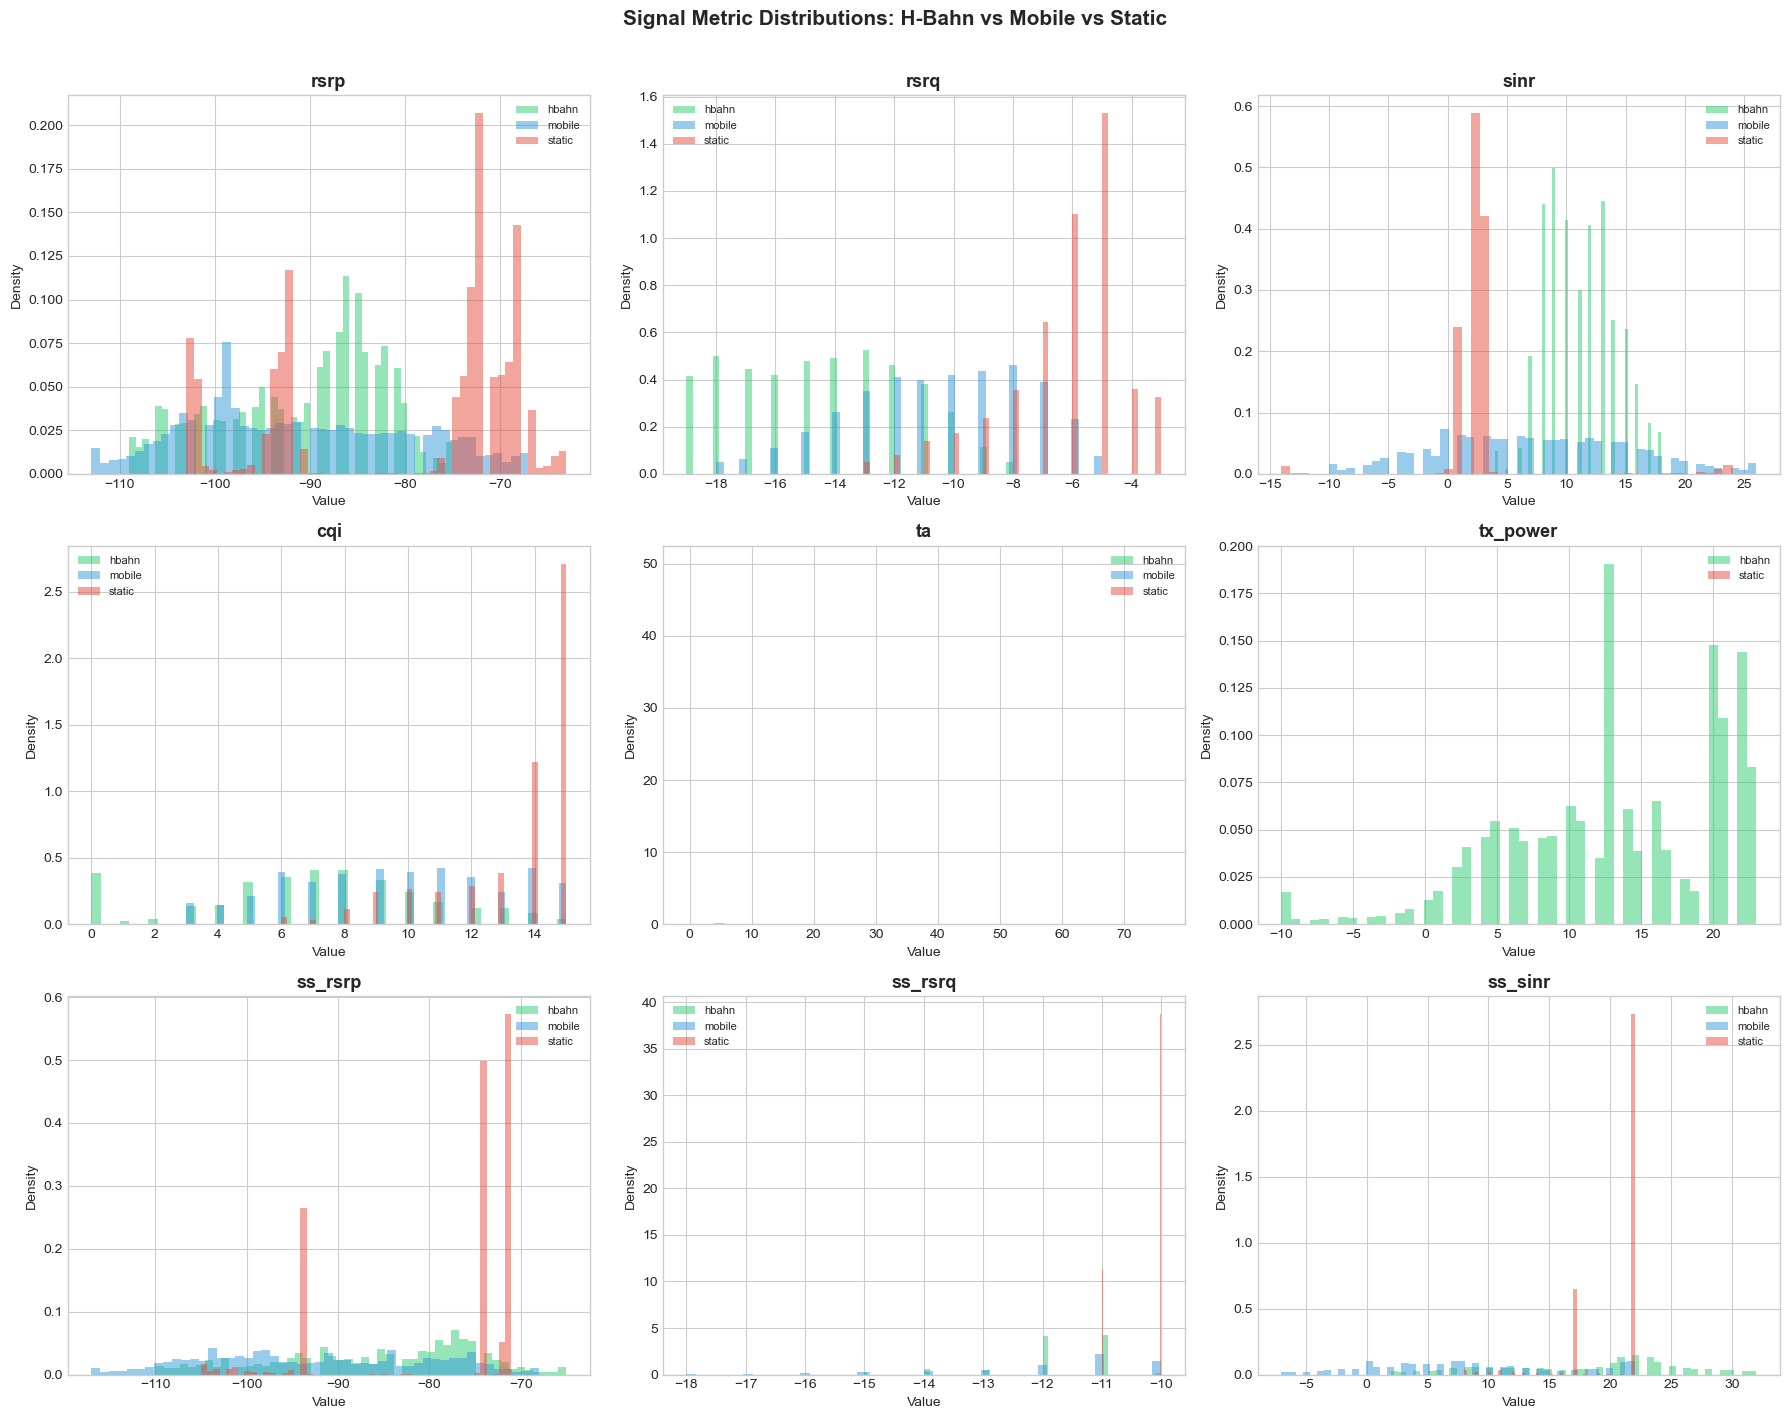

✅ Saved signal_distributions.png


In [94]:
SIGNAL_COLS = ['rsrp', 'rsrq', 'sinr', 'cqi', 'ta', 'tx_power',
               'ss_rsrp', 'ss_rsrq', 'ss_sinr']

# ── Distribution comparison across scenarios ──
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(SIGNAL_COLS):
    ax = axes[idx]
    plotted = False
    for scenario in ['hbahn', 'mobile', 'static']:
        if col not in raw[scenario].get('cell_data', pd.DataFrame()).columns:
            continue
        vals = raw[scenario]['cell_data'][col].dropna()
        # clip extreme outliers for visualization
        vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
        ax.hist(vals, bins=50, alpha=0.5, color=COLORS[scenario],
                label=scenario, density=True, edgecolor='none')
        plotted = True
    
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    if plotted:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Not available', ha='center',
                va='center', transform=ax.transAxes, color='gray')

plt.suptitle('Signal Metric Distributions: H-Bahn vs Mobile vs Static',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('signal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved signal_distributions.png')

In [95]:
# ── Numerical summary of every signal column ──
print('SIGNAL COLUMN STATISTICS BY SCENARIO')
print('='*70)

for col in SIGNAL_COLS:
    print(f'\n── {col} ──')
    rows = []
    for scenario in ['hbahn', 'mobile', 'static']:
        df = raw[scenario].get('cell_data', pd.DataFrame())
        if col not in df.columns:
            rows.append({'scenario': scenario, 'status': 'NOT IN FILE',
                         'missing%': '-', 'min': '-', 'mean': '-',
                         'max': '-', 'std': '-', 'unique': '-'})
        else:
            s = df[col]
            rows.append({
                'scenario': scenario,
                'missing%': f"{s.isnull().mean()*100:.1f}%",
                'min':      round(s.min(), 2),
                'mean':     round(s.mean(), 2),
                'max':      round(s.max(), 2),
                'std':      round(s.std(), 2),
                'unique':   s.nunique()
            })
    print(pd.DataFrame(rows).to_string(index=False))

SIGNAL COLUMN STATISTICS BY SCENARIO

── rsrp ──
scenario missing%      min    mean     max    std  unique
   hbahn     9.7% -122.000 -90.720 -55.000  8.560      66
  mobile     0.0% -140.000 -91.010 -56.000 11.550      70
  static     0.0% -127.000 -79.590 -57.000 12.540      53

── rsrq ──
scenario missing%     min    mean    max   std  unique
   hbahn    17.2% -19.000 -14.490 -3.000 2.910      17
  mobile     0.3% -19.000 -10.500 -3.000 3.020      17
  static     0.0% -16.000  -6.210 -3.000 2.080      14

── sinr ──
scenario missing%     min   mean    max   std  unique
   hbahn     9.7% -20.000 11.160 25.000 3.110      36
  mobile     0.0% -20.000  7.260 30.000 8.100      51
  static     0.0% -20.000  2.430 30.000 3.960      51

── cqi ──
scenario missing%   min   mean    max   std  unique
   hbahn     9.7% 0.000  6.930 15.000 3.740      16
  mobile     0.0% 1.000  9.590 15.000 3.390      15
  static     0.0% 1.000 13.520 15.000 2.150      15

── ta ──
scenario missing%   min   mean

---
## CELL 7 — Mobility features: velocity, bearing, GPS

These tell us HOW the user is moving.
Key question: does speed affect signal quality and handover behavior?

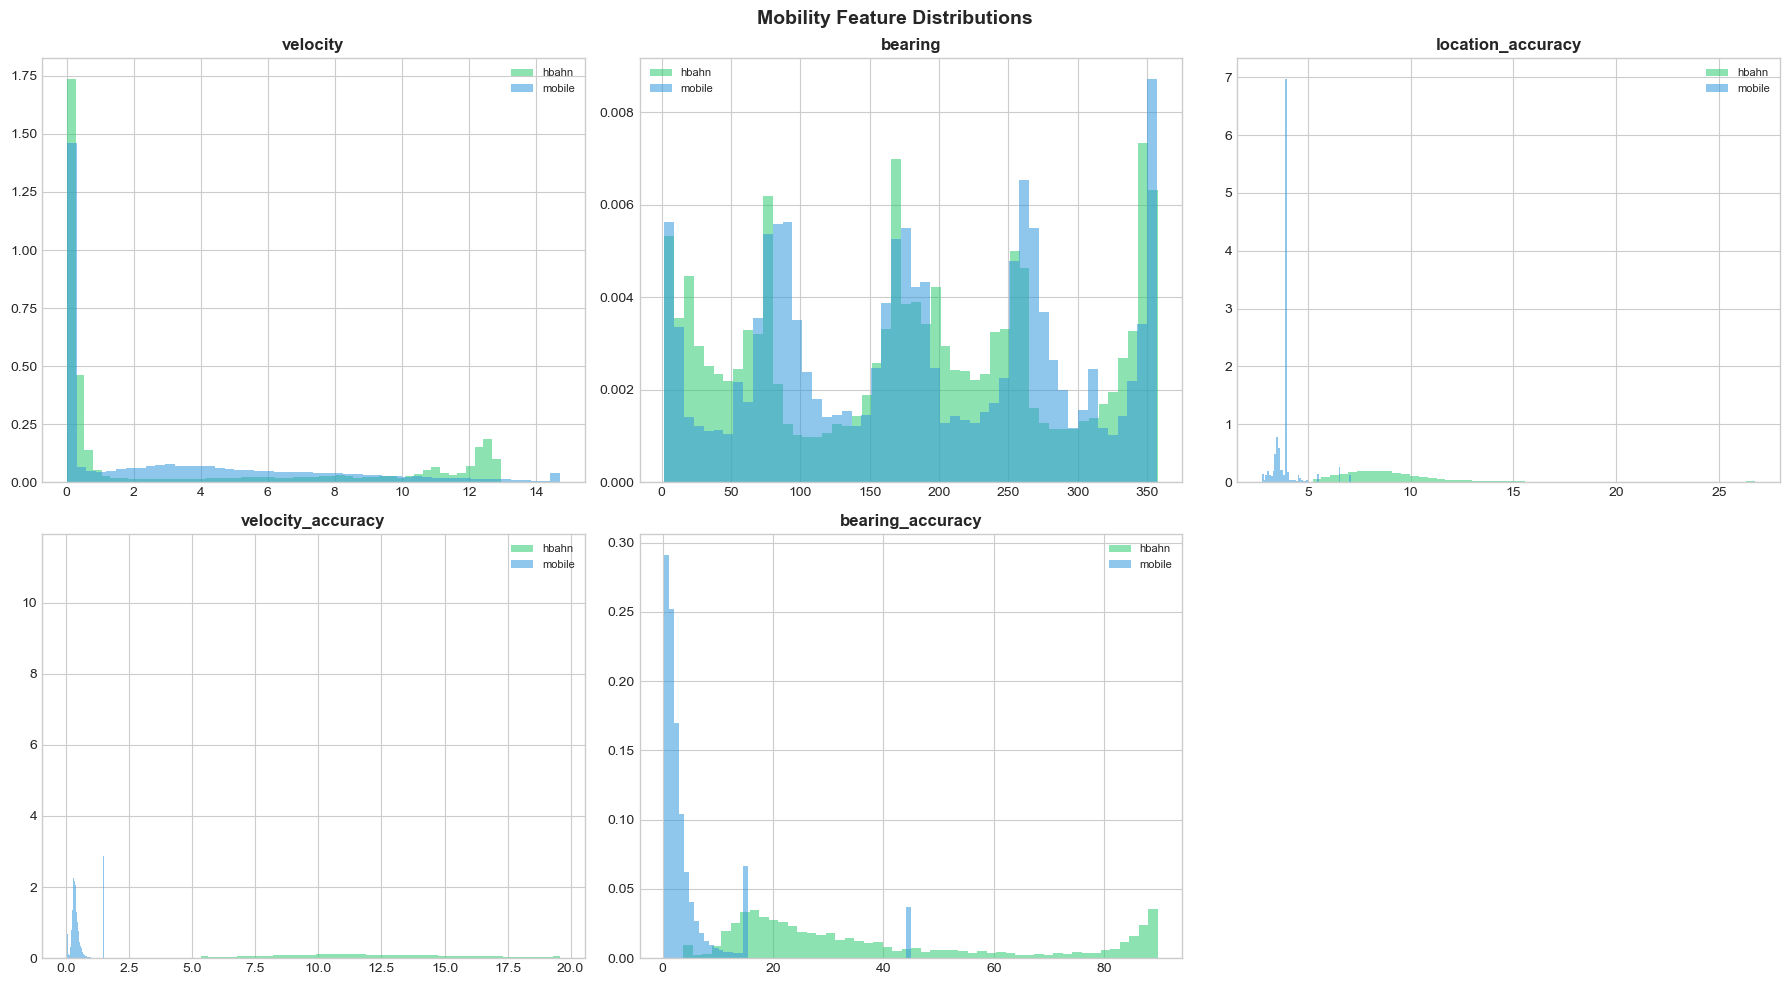

VELOCITY STATISTICS:
  hbahn   : mean=3.65 m/s (13.1 km/h)  max=15.81 m/s (56.9 km/h)  std=4.90
  mobile  : mean=3.23 m/s (11.6 km/h)  max=28.47 m/s (102.5 km/h)  std=3.97


In [97]:
MOB_COLS = ['velocity', 'bearing', 'location_accuracy',
            'velocity_accuracy', 'bearing_accuracy']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(MOB_COLS):
    ax = axes[idx]
    for scenario in ['hbahn', 'mobile', 'static']:
        df = raw[scenario].get('cell_data', pd.DataFrame())
        if col not in df.columns:
            continue
        vals = df[col].dropna()
        vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
        ax.hist(vals, bins=50, alpha=0.55, color=COLORS[scenario],
                label=scenario, density=True, edgecolor='none')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Mobility Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mobility_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Velocity stats ──
print('VELOCITY STATISTICS:')
for scenario in ['hbahn', 'mobile', 'static']:
    df = raw[scenario].get('cell_data', pd.DataFrame())
    if 'velocity' not in df.columns:
        continue
    v = df['velocity'].dropna()
    print(f'  {scenario:8s}: mean={v.mean():.2f} m/s '
          f'({v.mean()*3.6:.1f} km/h)  '
          f'max={v.max():.2f} m/s '
          f'({v.max()*3.6:.1f} km/h)  '
          f'std={v.std():.2f}')

---
## CELL 8 — QoS targets deep dive: latency and throughput

These are what we want to predict.
Key question: do they actually vary? Are they affected by radio conditions?

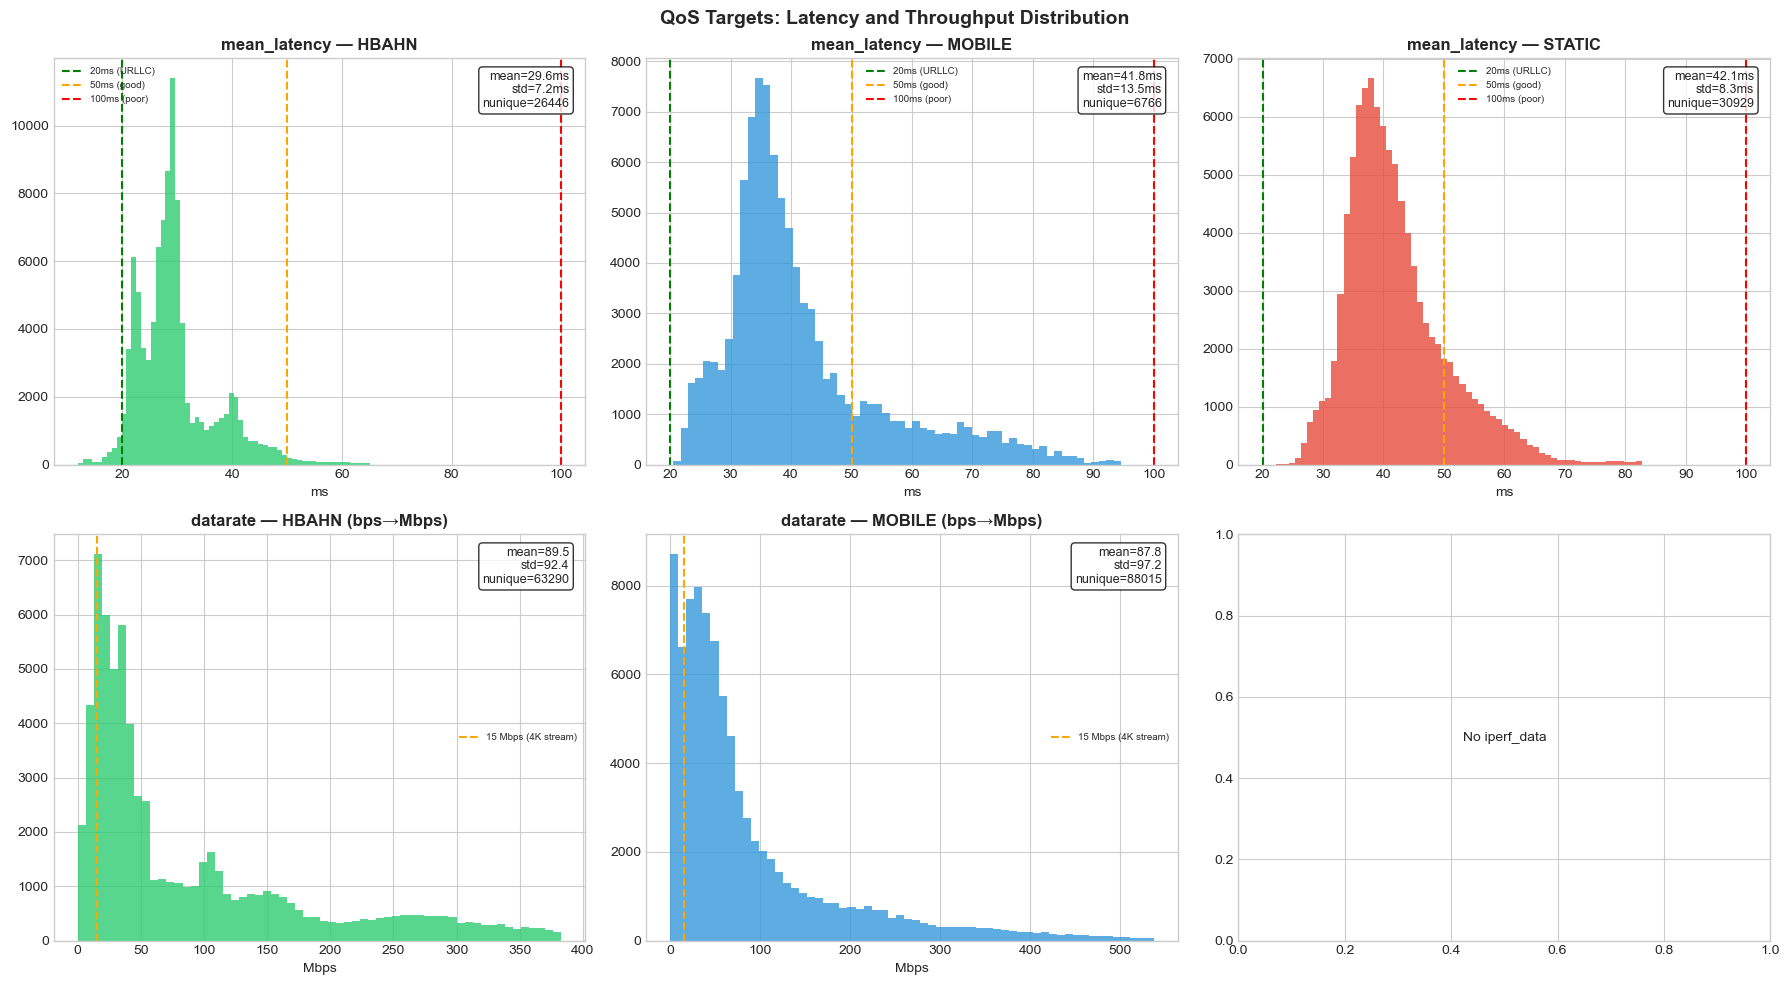


KEY OBSERVATION:
If mean_latency has very few unique values → it is near-constant → bad target
If datarate has many unique values and high std → good target


In [99]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Row 1: mean_latency ──
for col_idx, scenario in enumerate(['hbahn', 'mobile', 'static']):
    ax = axes[0, col_idx]
    df = raw[scenario].get('latency_data', pd.DataFrame())
    if 'mean_latency' not in df.columns:
        ax.text(0.5, 0.5, 'No latency_data', ha='center', va='center',
                transform=ax.transAxes)
        continue
    lat = df['mean_latency'].dropna()
    lat = lat[lat < lat.quantile(0.99)]
    ax.hist(lat, bins=60, color=COLORS[scenario], alpha=0.8, edgecolor='none')
    ax.axvline(20,  color='green',  linestyle='--', lw=1.5, label='20ms (URLLC)')
    ax.axvline(50,  color='orange', linestyle='--', lw=1.5, label='50ms (good)')
    ax.axvline(100, color='red',    linestyle='--', lw=1.5, label='100ms (poor)')
    ax.set_title(f'mean_latency — {scenario.upper()}', fontweight='bold')
    ax.set_xlabel('ms')
    ax.legend(fontsize=7)
    # Print key stats as text on plot
    ax.text(0.97, 0.97,
            f'mean={lat.mean():.1f}ms\nstd={lat.std():.1f}ms\n'
            f'nunique={lat.nunique()}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Row 2: datarate ──
for col_idx, scenario in enumerate(['hbahn', 'mobile', 'static']):
    ax = axes[1, col_idx]
    df = raw[scenario].get('iperf_data', pd.DataFrame())
    if df is None or 'datarate' not in df.columns:
        ax.text(0.5, 0.5, 'No iperf_data', ha='center', va='center',
                transform=ax.transAxes)
        continue
    dr = df['datarate'].dropna()
    # unit conversion check
    if dr.median() > 1_000_000:
        dr = dr / 1_000_000
        unit = 'bps→Mbps'
    elif dr.median() > 1_000:
        dr = dr / 1_000
        unit = 'kbps→Mbps'
    else:
        unit = 'Mbps'
    dr = dr[dr > 0]
    dr = dr[dr < dr.quantile(0.99)]
    ax.hist(dr, bins=60, color=COLORS[scenario], alpha=0.8, edgecolor='none')
    ax.axvline(15, color='orange', linestyle='--', lw=1.5, label='15 Mbps (4K stream)')
    ax.set_title(f'datarate — {scenario.upper()} ({unit})', fontweight='bold')
    ax.set_xlabel('Mbps')
    ax.legend(fontsize=7)
    ax.text(0.97, 0.97,
            f'mean={dr.mean():.1f}\nstd={dr.std():.1f}\n'
            f'nunique={dr.nunique()}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('QoS Targets: Latency and Throughput Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('qos_targets.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKEY OBSERVATION:')
print('If mean_latency has very few unique values → it is near-constant → bad target')
print('If datarate has many unique values and high std → good target')

---
## CELL 9 — Static scenario deep dive

Static phones don't move → any signal change = NETWORK change, not user movement.
This means Static can tell us about cell load over time.

We explore: does signal quality in Static vary over time? By how much?

In [101]:
print('STATIC SCENARIO — Deep Dive')
print('='*60)

df_static = raw['static']['cell_data'].copy()
locs      = raw['static'].get('static_locations', pd.DataFrame())

print('\nThe 4 fixed measurement locations:')
print(locs.to_string(index=False))

print(f'\nStatic cell_data: {df_static.shape}')
print(f'Columns: {df_static.columns.tolist()}')

# How many unique towers are visible from static locations?
if 'physical_cellid' in df_static.columns:
    print(f'\nUnique towers seen from static phones: '
          f'{df_static["physical_cellid"].nunique()}')
    print('\nTop towers by measurement count:')
    print(df_static['physical_cellid'].value_counts().head(10))

# Signal variation in static — this is the key question
sig_cols = [c for c in ['rsrp','sinr','rsrq','cqi','tx_power']
            if c in df_static.columns]

print('\nSIGNAL VARIATION IN STATIC (phone not moving!):')
print('High std = network is changing = load/interference variation')
print()
for col in sig_cols:
    s = df_static[col].dropna()
    cv = s.std() / abs(s.mean()) * 100 if s.mean() != 0 else 0
    useful = '✅ VARIES — potentially useful' if s.std() > 2 else '❌ near constant'
    print(f'  {col:15s}: mean={s.mean():8.2f}  std={s.std():6.2f}  '
          f'CV={cv:5.1f}%  → {useful}')

STATIC SCENARIO — Deep Dive

The 4 fixed measurement locations:
username  latitude  longitude  altitude
 Static1    51.504      7.463   127.187
 Static2    51.511      7.465   111.000
 Static3    51.500      7.441   110.717
 Static4    51.492      7.417   165.232

Static cell_data: (100000, 37)
Columns: ['id', 'session_id', 'timestamp', 'network', 'cell_index', 'physical_cellid', 'tracking_area_code', 'earfcn', 'rsrp', 'rsrq', 'rssi', 'sinr', 'ta', 'cqi', 'primary_bandwidth', 'cellbandwidths', 'ul_bandwidth', 'lte_mcs', 'lte_ri', 'nr_mcs', 'nr_ri', 'tx_power', 'mcc', 'mnc', 'ss_rsrp', 'ss_rsrq', 'ss_sinr', 'device', 'devicename', 'twog_possible', 'threeg_possible', 'fourg_possible', 'fiveg_nsa_possible', 'fiveg_sa_possible', 'username', 'session_start_timestamp', 'MNO']

Unique towers seen from static phones: 14

Top towers by measurement count:
physical_cellid
265.000    52627
174.000    22234
64.000     12022
93.000     10127
311.000     1456
218.000      944
127.000      463
157.000

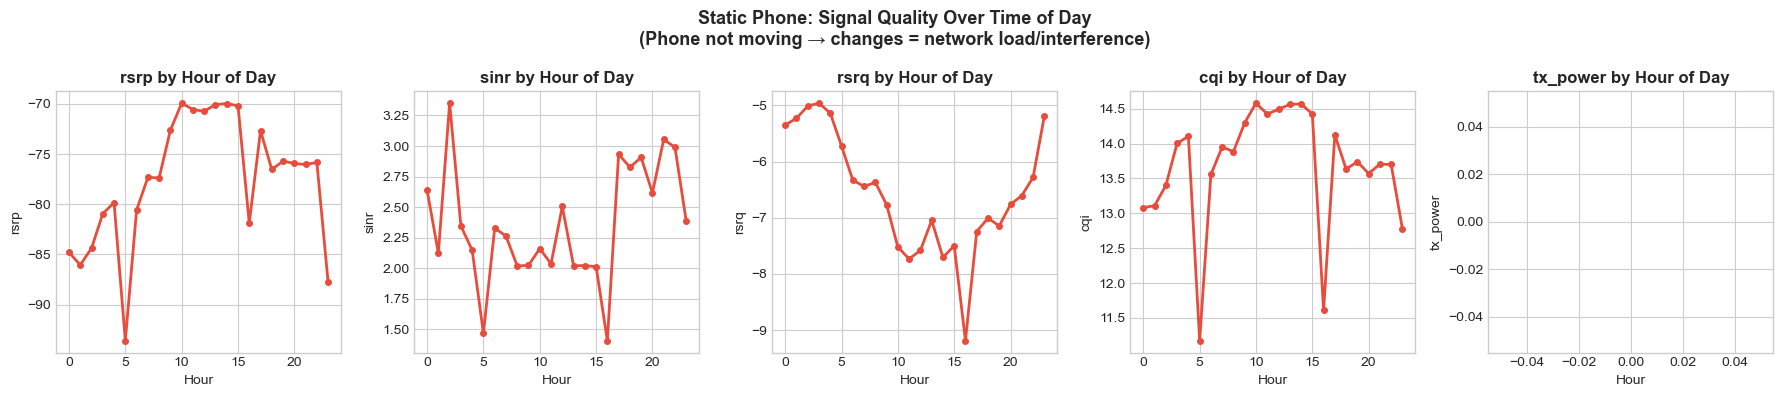

✅ Saved static_temporal.png

If signal drops at peak hours → this is cell load!


In [102]:
# ── If there are timestamps, show signal over time ──
ts_col = next((c for c in ['timestamp','timestampstart'] 
               if c in df_static.columns), None)

if ts_col:
    df_s = df_static.copy()
    df_s['ts_num'] = pd.to_numeric(df_s[ts_col], errors='coerce')
    df_s = df_s.dropna(subset=['ts_num']).sort_values('ts_num')
    
    # Convert to datetime if Unix
    med = df_s['ts_num'].median()
    if med > 1e12:
        df_s['datetime'] = pd.to_datetime(df_s['ts_num'], unit='ms')
    elif med > 1e9:
        df_s['datetime'] = pd.to_datetime(df_s['ts_num'], unit='s')
    else:
        df_s['datetime'] = None
    
    if df_s['datetime'].notna().any():
        df_s['hour'] = df_s['datetime'].dt.hour
        
        # Plot signal by hour of day
        fig, axes = plt.subplots(1, len(sig_cols), figsize=(18, 4))
        if len(sig_cols) == 1:
            axes = [axes]
        
        for ax, col in zip(axes, sig_cols):
            hourly = df_s.groupby('hour')[col].mean()
            ax.plot(hourly.index, hourly.values,
                    color=COLORS['static'], linewidth=2, marker='o', markersize=4)
            ax.set_title(f'{col} by Hour of Day', fontweight='bold')
            ax.set_xlabel('Hour')
            ax.set_ylabel(col)
        
        plt.suptitle('Static Phone: Signal Quality Over Time of Day\n'
                     '(Phone not moving → changes = network load/interference)',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('static_temporal.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('✅ Saved static_temporal.png')
        print('\nIf signal drops at peak hours → this is cell load!')
    else:
        print('Could not parse timestamps to datetime')
else:
    print('No timestamp column found in static cell_data')

---
## CELL 10 — Neighboring data deep dive

This is the most underused file in the project.
It tells us: what other towers are available at each moment?
Key question: are neighboring towers competitive with the serving cell?

NEIGHBORING DATA DEEP DIVE

HBAHN:
  Shape: (100000, 20)
  Columns: ['network_neighboring', 'physical_cellid_neighboring', 'tracking_area_code_neighboring', 'earfcn_neighboring', 'rsrp_neighboring', 'rsrq_neighboring', 'rssi_neighboring', 'sinr_neighboring', 'mcc_neighboring', 'mnc_neighboring', 'device', 'latitude', 'longitude', 'altitude', 'location_accuracy', 'velocity', 'velocity_accuracy', 'bearing', 'bearing_accuracy', 'MNO_neighboring']

  RSRP comparison:
    Serving  → mean=-90.7  std=8.6  min=-122.0  max=-55.0
    Neighbor → mean=-92.8  std=10.3  min=-131.0  max=-48.0

  % of neighbor readings STRONGER than avg serving: 41.8%
  → This means handover opportunities exist 42% of the time

MOBILE:
  Shape: (100000, 23)
  Columns: ['network_neighboring', 'physical_cellid_neighboring', 'tracking_area_code_neighboring', 'earfcn_neighboring', 'rsrp_neighboring', 'rsrq_neighboring', 'rssi_neighboring', 'sinr_neighboring', 'mcc_neighboring', 'mnc_neighboring', 'passive_id', 'device', '

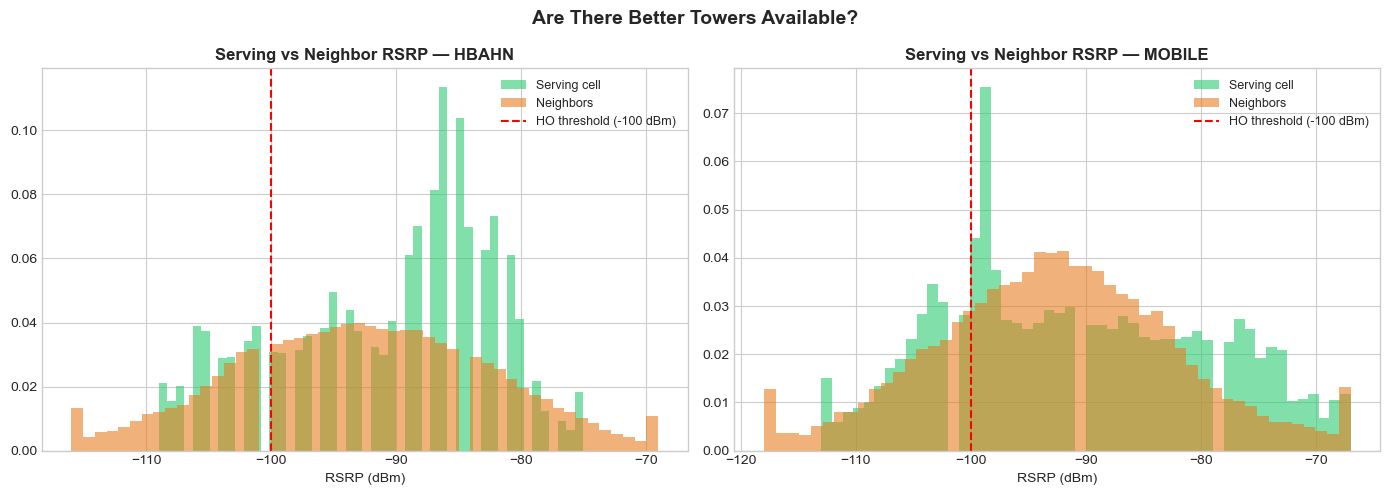

✅ Saved serving_vs_neighbor.png


In [104]:
print('NEIGHBORING DATA DEEP DIVE')
print('='*60)

for scenario in ['hbahn', 'mobile']:
    df_n = raw[scenario].get('neighboring_data', pd.DataFrame())
    df_c = raw[scenario].get('cell_data', pd.DataFrame())
    
    print(f'\n{scenario.upper()}:')
    print(f'  Shape: {df_n.shape}')
    print(f'  Columns: {df_n.columns.tolist()}')
    
    # How many neighbors per timestamp?
    ts_col = next((c for c in ['timestamp','timestampstart'] 
                   if c in df_n.columns), None)
    if ts_col:
        nbr_per_ts = df_n.groupby(ts_col).size()
        print(f'\n  Neighbors detected per scan:')
        print(f'    mean:   {nbr_per_ts.mean():.1f}')
        print(f'    median: {nbr_per_ts.median():.0f}')
        print(f'    max:    {nbr_per_ts.max()}')
        print(f'    min:    {nbr_per_ts.min()}')
    
    # Compare neighbor signal to serving cell
    if 'rsrp_neighboring' in df_n.columns and 'rsrp' in df_c.columns:
        nbr_rsrp  = df_n['rsrp_neighboring'].dropna()
        serv_rsrp = df_c['rsrp'].dropna()
        
        print(f'\n  RSRP comparison:')
        print(f'    Serving  → mean={serv_rsrp.mean():.1f}  '
              f'std={serv_rsrp.std():.1f}  '
              f'min={serv_rsrp.min():.1f}  '
              f'max={serv_rsrp.max():.1f}')
        print(f'    Neighbor → mean={nbr_rsrp.mean():.1f}  '
              f'std={nbr_rsrp.std():.1f}  '
              f'min={nbr_rsrp.min():.1f}  '
              f'max={nbr_rsrp.max():.1f}')
        
        pct_stronger = (nbr_rsrp > serv_rsrp.mean()).mean() * 100
        print(f'\n  % of neighbor readings STRONGER than avg serving: '
              f'{pct_stronger:.1f}%')
        print(f'  → This means handover opportunities exist {pct_stronger:.0f}% of the time')

# ── Plot serving vs neighbor RSRP ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scenario in zip(axes, ['hbahn', 'mobile']):
    df_n = raw[scenario].get('neighboring_data', pd.DataFrame())
    df_c = raw[scenario].get('cell_data', pd.DataFrame())
    if 'rsrp_neighboring' not in df_n.columns or 'rsrp' not in df_c.columns:
        continue
    
    serv = df_c['rsrp'].dropna()
    nbr  = df_n['rsrp_neighboring'].dropna()
    serv = serv.clip(serv.quantile(0.01), serv.quantile(0.99))
    nbr  = nbr.clip(nbr.quantile(0.01), nbr.quantile(0.99))
    
    ax.hist(serv, bins=50, alpha=0.6, color='#2ecc71',
            label='Serving cell', density=True)
    ax.hist(nbr,  bins=50, alpha=0.6, color='#e67e22',
            label='Neighbors', density=True)
    ax.axvline(-100, color='red', linestyle='--', lw=1.5,
               label='HO threshold (-100 dBm)')
    ax.set_title(f'Serving vs Neighbor RSRP — {scenario.upper()}',
                 fontweight='bold')
    ax.set_xlabel('RSRP (dBm)')
    ax.legend(fontsize=9)

plt.suptitle('Are There Better Towers Available?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('serving_vs_neighbor.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved serving_vs_neighbor.png')

---
## CELL 11 — Correlation analysis: what relates to what?

Before deciding features, we need to understand:
1. Which radio features are correlated with each other? (redundant pairs to remove)
2. Which features correlate with the TARGET (datarate)?
3. Which features are truly independent and add information?

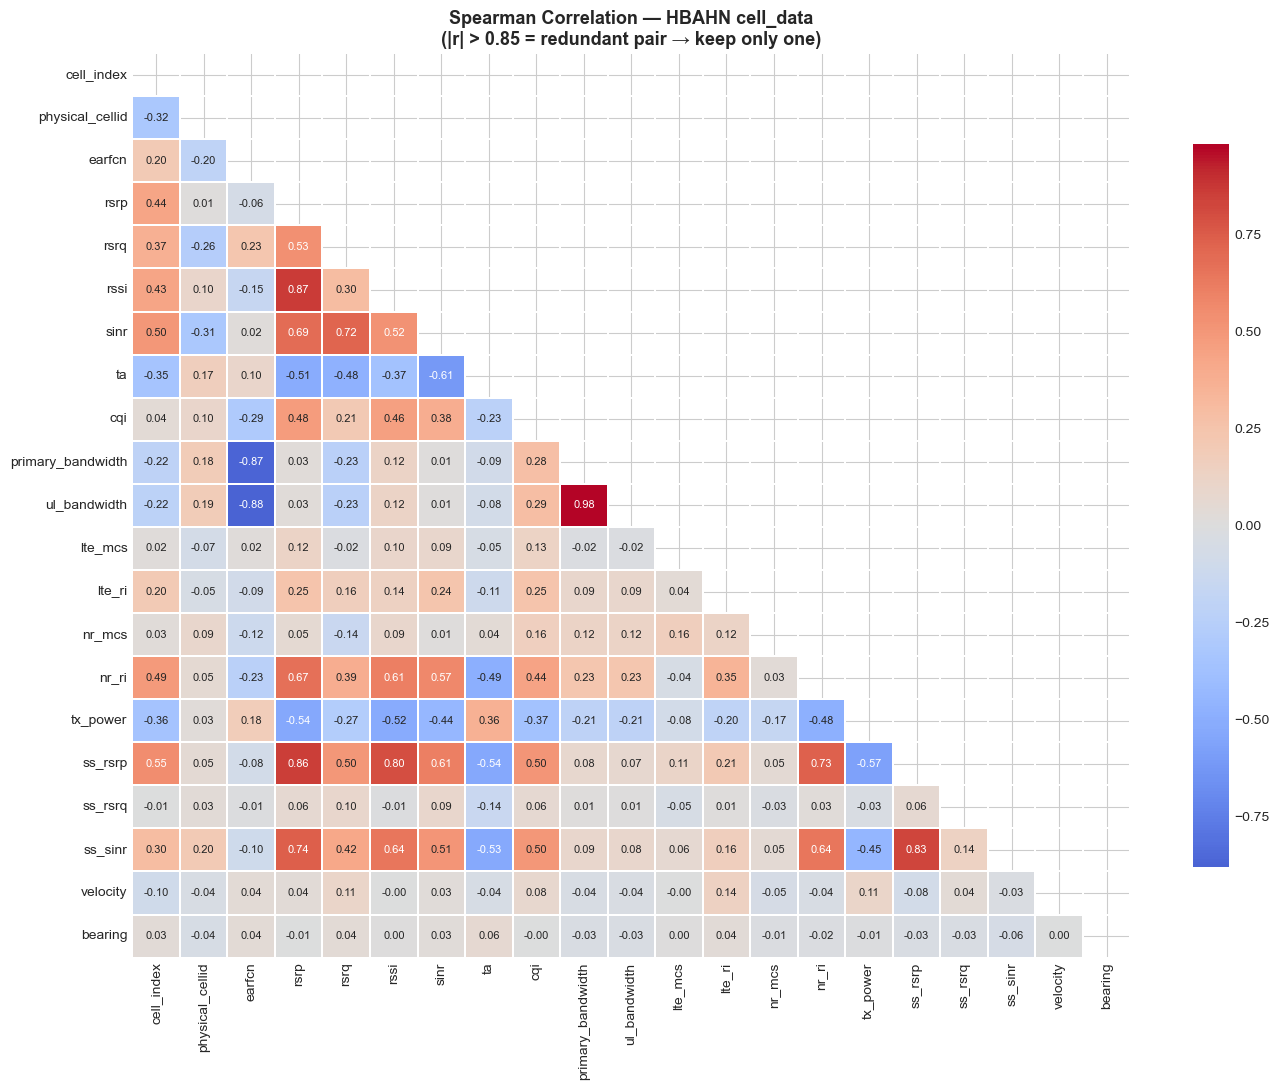


HIGHLY CORRELATED PAIRS in hbahn (|r| > 0.80):
These are redundant — keeping both adds no information
  primary_bandwidth    ↔ ul_bandwidth          r=0.985
  rsrp                 ↔ rssi                  r=0.867
  rsrp                 ↔ ss_rsrp               r=0.857
  ss_rsrp              ↔ ss_sinr               r=0.826
  rssi                 ↔ ss_rsrp               r=0.802
  earfcn               ↔ primary_bandwidth     r=-0.870
  earfcn               ↔ ul_bandwidth          r=-0.881



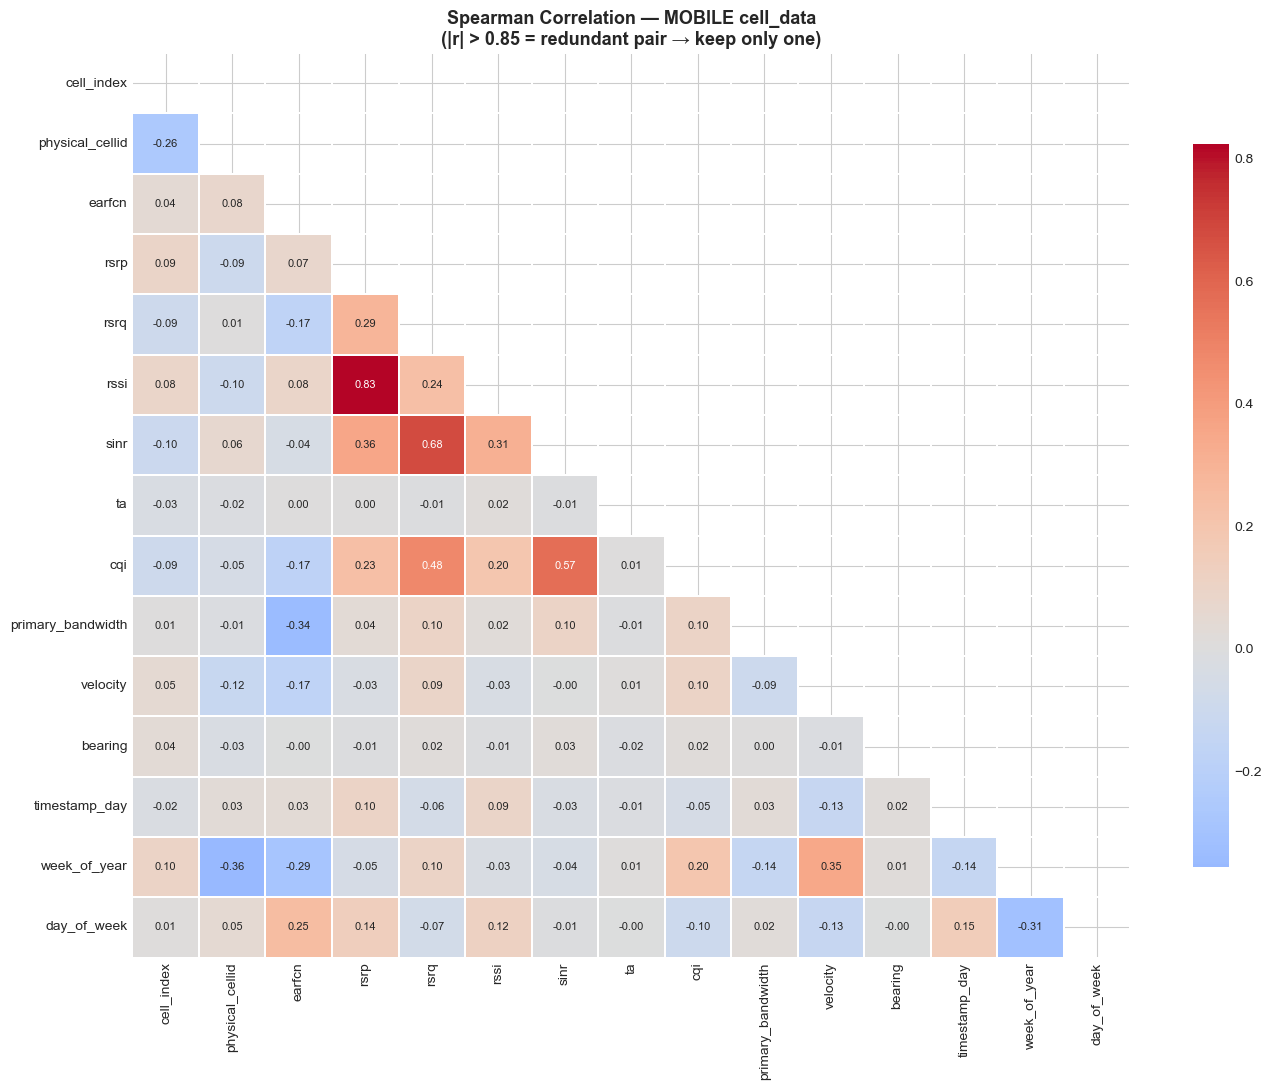


HIGHLY CORRELATED PAIRS in mobile (|r| > 0.80):
These are redundant — keeping both adds no information
  rsrp                 ↔ rssi                  r=0.825



In [106]:
# ── Correlation matrix for cell_data ──
META = ['network','mcc','mnc','MNO','device','cellbandwidths',
        'tracking_area_code','timestamp','timestampstart',
        'timestampend','bearing_accuracy','velocity_accuracy',
        'location_accuracy','latitude','longitude','altitude',
        'passive_id','username','session_id']

for scenario in ['hbahn', 'mobile']:
    df = raw[scenario]['cell_data'].copy()
    df = df.drop(columns=[c for c in META if c in df.columns], errors='ignore')
    df = df.select_dtypes(include='number')
    df = df.dropna(axis=1, thresh=int(0.5 * len(df)))
    
    corr = df.corr(method='spearman')
    
    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, linewidths=0.3,
                ax=ax, cbar_kws={'shrink': 0.8},
                annot_kws={'size': 8})
    ax.set_title(f'Spearman Correlation — {scenario.upper()} cell_data\n'
                 f'(|r| > 0.85 = redundant pair → keep only one)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'correlation_{scenario}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print highly correlated pairs
    print(f'\nHIGHLY CORRELATED PAIRS in {scenario} (|r| > 0.80):')
    print('These are redundant — keeping both adds no information')
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack()
    high  = pairs[pairs.abs() > 0.80].sort_values(ascending=False)
    if len(high) == 0:
        print('  None found above threshold')
    for (c1, c2), r in high.items():
        print(f'  {c1:20s} ↔ {c2:20s}  r={r:.3f}')
    print()

---
## CELL 12 — How does signal relate to throughput?

This is the most important question for DSO4.
If signal quality does NOT correlate with throughput,
then using signal features to predict throughput won't work.

Let's check before building any model.

In [108]:
print('SIGNAL vs THROUGHPUT CORRELATION')
print('='*60)
print('Can radio features predict datarate? Let us check before modeling.')
print()

for scenario in ['hbahn', 'mobile']:
    df_ip = raw[scenario].get('iperf_data', pd.DataFrame())
    if df_ip is None or 'datarate' not in df_ip.columns:
        print(f'{scenario}: no iperf_data'); continue
    
    # normalize datarate
    dr = df_ip['datarate'].dropna()
    if dr.median() > 1_000_000: df_ip['datarate'] = df_ip['datarate'] / 1_000_000
    elif dr.median() > 1_000:   df_ip['datarate'] = df_ip['datarate'] / 1_000
    df_ip = df_ip[df_ip['datarate'] > 0]
    
    sig_cols_avail = [c for c in ['rsrp','rsrq','sinr','cqi','ta',
                                   'tx_power','ss_rsrp','ss_sinr',
                                   'velocity','lte_mcs','nr_mcs']
                      if c in df_ip.columns]
    
    print(f'{scenario.upper()} — Spearman correlation with datarate:')
    correlations = []
    for col in sig_cols_avail:
        s = df_ip[col].dropna()
        if len(s) < 100: continue
        aligned = df_ip[['datarate', col]].dropna()
        if len(aligned) < 50: continue
        r, p = stats.spearmanr(aligned['datarate'], aligned[col])
        strength = ('🔴 STRONG' if abs(r) > 0.5 else
                    '🟡 MODERATE' if abs(r) > 0.3 else
                    '⚪ WEAK')
        correlations.append((col, r, p, strength))
    
    correlations.sort(key=lambda x: abs(x[1]), reverse=True)
    for col, r, p, strength in correlations:
        print(f'  {col:20s}  r={r:+.3f}  {strength}')
    print()

print('INTERPRETATION:')
print('  r > 0.5  = feature is strongly predictive of throughput → KEEP')
print('  r 0.3-0.5 = moderately predictive → likely keep')
print('  r < 0.3  = weak → evaluate carefully')
print('  negative r means: as this increases, throughput decreases')
print('  (e.g. tx_power: higher tx_power = struggling = lower throughput)')

SIGNAL vs THROUGHPUT CORRELATION
Can radio features predict datarate? Let us check before modeling.

HBAHN — Spearman correlation with datarate:
  tx_power              r=-0.227  ⚪ WEAK
  cqi                   r=+0.220  ⚪ WEAK
  lte_mcs               r=+0.209  ⚪ WEAK
  nr_mcs                r=+0.202  ⚪ WEAK
  ss_rsrp               r=+0.193  ⚪ WEAK
  rsrp                  r=+0.191  ⚪ WEAK
  sinr                  r=+0.181  ⚪ WEAK
  ss_sinr               r=+0.153  ⚪ WEAK
  ta                    r=-0.144  ⚪ WEAK
  rsrq                  r=+0.090  ⚪ WEAK
  velocity              r=-0.039  ⚪ WEAK

MOBILE — Spearman correlation with datarate:
  rsrp                  r=+0.222  ⚪ WEAK
  rsrq                  r=+0.207  ⚪ WEAK
  ss_rsrp               r=+0.200  ⚪ WEAK
  sinr                  r=+0.168  ⚪ WEAK
  cqi                   r=+0.149  ⚪ WEAK
  ss_sinr               r=+0.096  ⚪ WEAK
  ta                    r=-0.041  ⚪ WEAK
  velocity              r=+0.035  ⚪ WEAK

INTERPRETATION:
  r > 0.5  = 

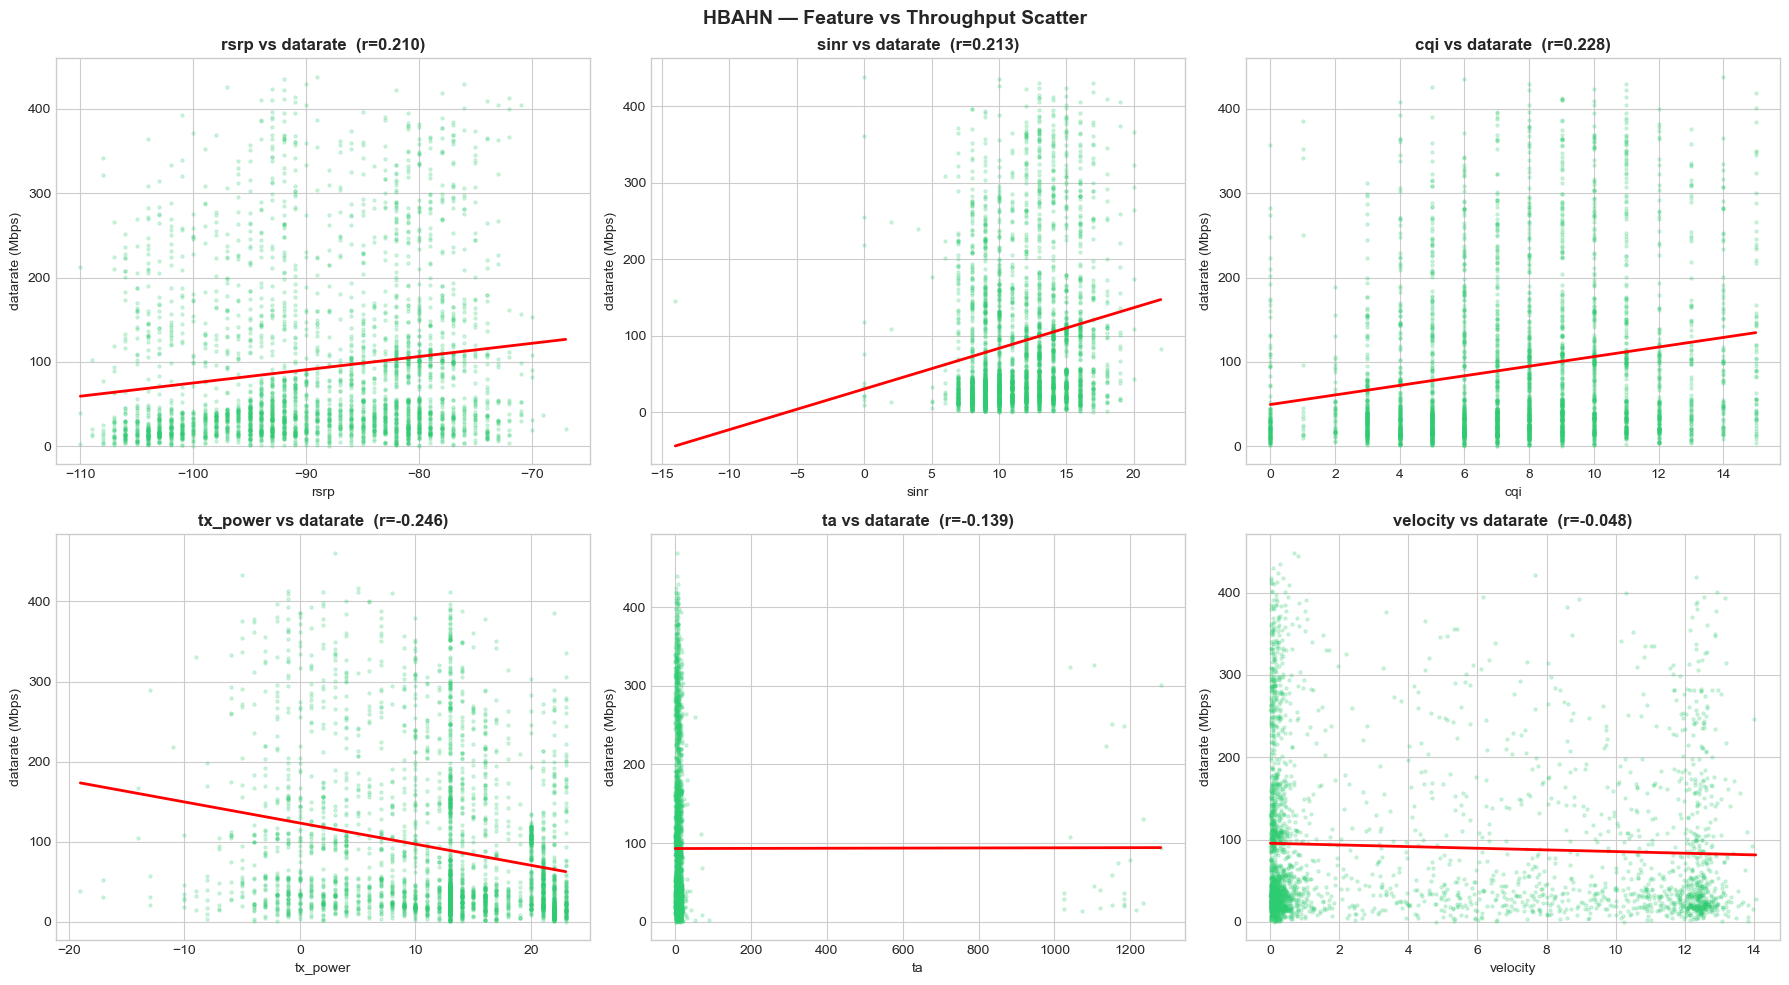

✅ Saved scatter_hbahn.png


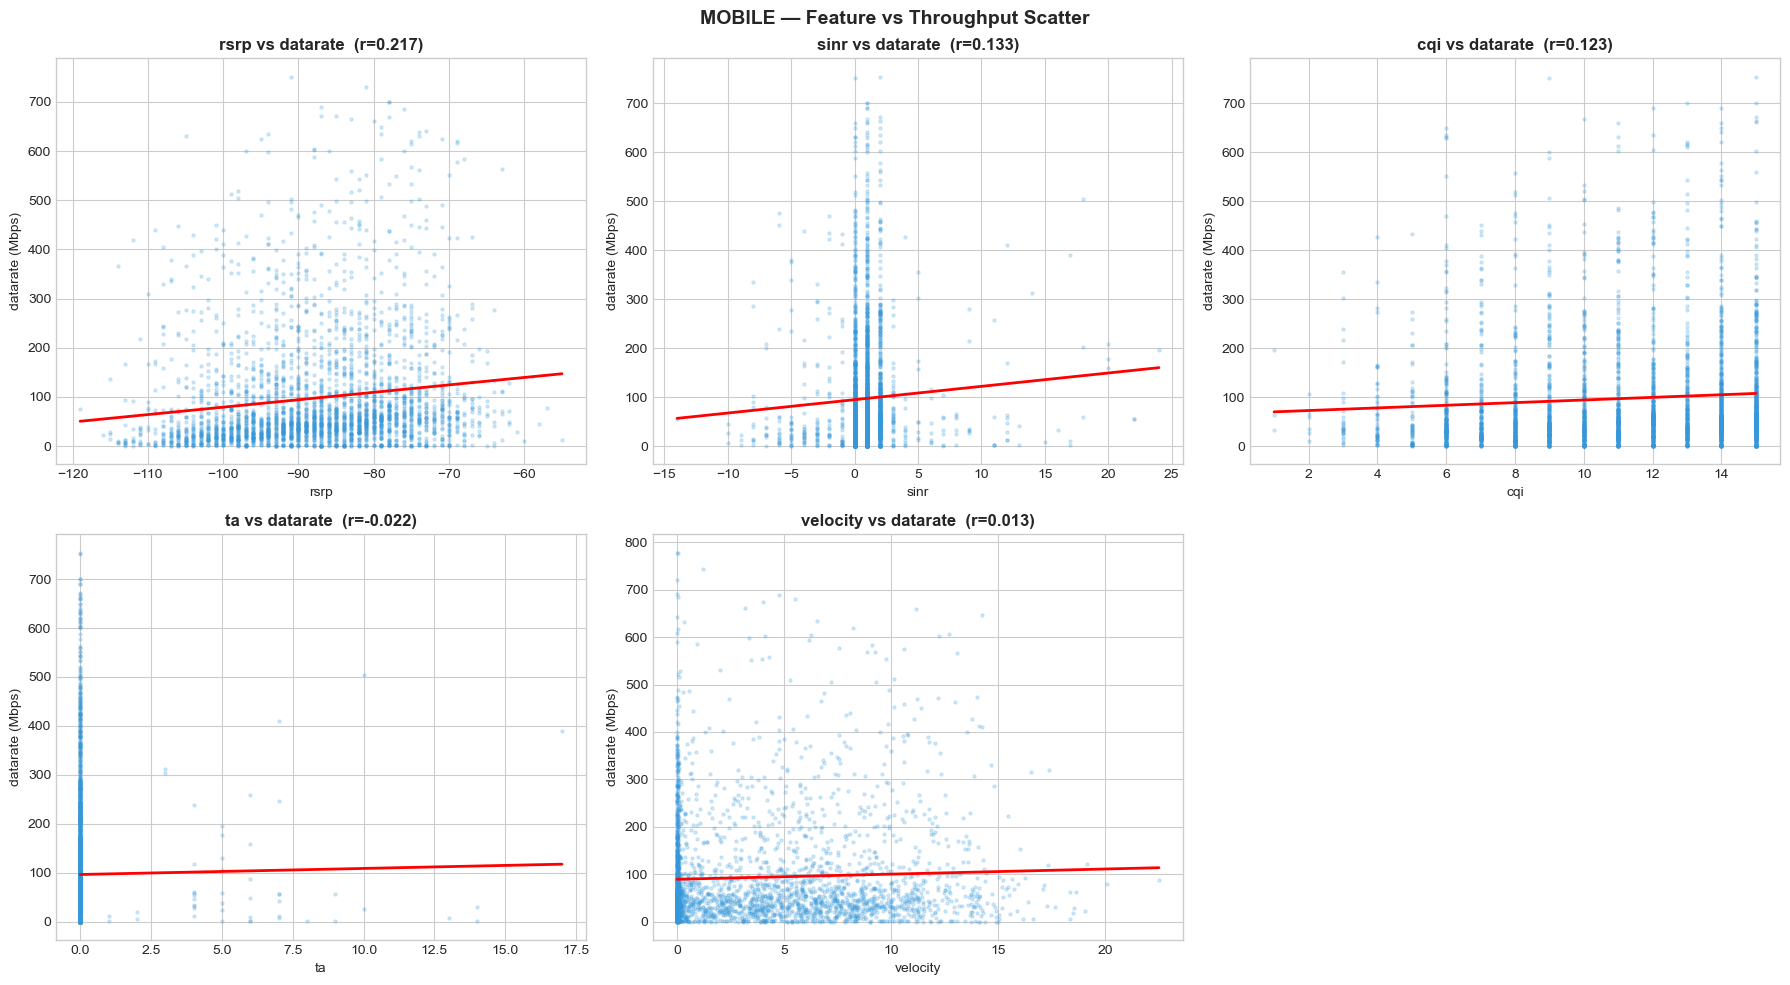

✅ Saved scatter_mobile.png


In [109]:
# ── Scatter plots: top features vs datarate ──
TOP_FEATURES = ['rsrp', 'sinr', 'cqi', 'tx_power', 'ta', 'velocity']

for scenario in ['hbahn', 'mobile']:
    df_ip = raw[scenario].get('iperf_data', pd.DataFrame())
    if df_ip is None or 'datarate' not in df_ip.columns:
        continue
    
    dr = df_ip['datarate'].copy()
    if dr.median() > 1_000_000: df_ip['datarate'] = dr / 1_000_000
    elif dr.median() > 1_000:   df_ip['datarate'] = dr / 1_000
    df_ip = df_ip[df_ip['datarate'] > 0]
    
    avail = [c for c in TOP_FEATURES if c in df_ip.columns]
    if not avail: continue
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(avail[:6]):
        ax  = axes[idx]
        sub = df_ip[['datarate', col]].dropna().sample(
            min(3000, len(df_ip)), random_state=42)
        ax.scatter(sub[col], sub['datarate'],
                   alpha=0.2, s=5, color=COLORS[scenario])
        # Add trend line
        try:
            z = np.polyfit(sub[col], sub['datarate'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(sub[col].min(), sub[col].max(), 100)
            ax.plot(x_line, p(x_line), 'r-', linewidth=2, label='trend')
        except Exception:
            pass
        r, _ = stats.spearmanr(sub['datarate'], sub[col])
        ax.set_title(f'{col} vs datarate  (r={r:.3f})', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('datarate (Mbps)')
    
    for i in range(len(avail), 6):
        axes[i].set_visible(False)
    
    plt.suptitle(f'{scenario.upper()} — Feature vs Throughput Scatter',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'scatter_{scenario}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved scatter_{scenario}.png')

---
## CELL 13 — Feature selection decision table

Based on everything we saw above, we now make explicit decisions:
- KEEP: feature has variance, correlates with target, not redundant
- DROP: constant, 100% missing, pure metadata, redundant with another feature
- MAYBE: some value but limited — evaluate after seeing correlation results

In [111]:
# This cell summarizes our feature selection decisions
# UPDATE the 'decision' column after looking at your correlation results above

feature_decisions = [
    # SIGNAL QUALITY
    {'feature': 'rsrp',             'type': 'signal',   'decision': 'KEEP',
     'reason': 'Primary signal strength. Drops at cell edge = HO trigger. '
               'Directly tied to achievable datarate.'},
    {'feature': 'rsrq',             'type': 'signal',   'decision': 'KEEP',
     'reason': 'Signal quality including interference. Different from rsrp. '
               'Good in low-interference environments.'},
    {'feature': 'sinr',             'type': 'signal',   'decision': 'KEEP',
     'reason': 'Best single predictor of link quality. '
               'Low sinr = interference = low throughput.'},
    {'feature': 'rssi',             'type': 'signal',   'decision': 'CHECK',
     'reason': 'Total received power. Often 90%+ correlated with rsrp. '
               'Drop if corr(rsrp,rssi) > 0.85.'},
    {'feature': 'ss_rsrp',          'type': 'signal_5g','decision': 'KEEP',
     'reason': '5G version of rsrp. Has ~9% missing. '
               'Keep — impute missing with median.'},
    {'feature': 'ss_rsrq',          'type': 'signal_5g','decision': 'CHECK',
     'reason': '5G version of rsrq. Check correlation with rsrq.'},
    {'feature': 'ss_sinr',          'type': 'signal_5g','decision': 'KEEP',
     'reason': '5G sinr. Different from 4G sinr. '
               'Useful if 5G coverage exists.'},
    # LINK ADAPTATION
    {'feature': 'cqi',              'type': 'link',     'decision': 'KEEP',
     'reason': 'Phone feedback to tower about achievable speed. '
               'Direct proxy for potential throughput.'},
    {'feature': 'lte_mcs',          'type': 'link',     'decision': 'KEEP',
     'reason': 'How aggressively data is being encoded. '
               'High = good conditions. Check for redundancy with cqi.'},
    {'feature': 'lte_ri',           'type': 'link',     'decision': 'KEEP',
     'reason': 'Number of MIMO streams. More streams = more speed potential.'},
    {'feature': 'nr_mcs',           'type': 'link',     'decision': 'MAYBE',
     'reason': '5G MCS. Check missing %. May not exist in all rows.'},
    {'feature': 'nr_ri',            'type': 'link',     'decision': 'MAYBE',
     'reason': '5G RI. Same as above.'},
    # PHONE BEHAVIOR
    {'feature': 'tx_power',         'type': 'phone',    'decision': 'KEEP',
     'reason': 'How hard phone shouts at tower. '
               'High = struggling = likely negative correlation with throughput.'},
    {'feature': 'ta',               'type': 'phone',    'decision': 'KEEP',
     'reason': 'Distance from tower. '
               'High ta = cell edge = about to hand over.'},
    # CELL IDENTITY
    {'feature': 'physical_cellid',  'type': 'identity', 'decision': 'HO ONLY',
     'reason': 'Used ONLY to detect handovers (PCI change). '
               'Not a model input — each tower has a different ID with no ordinal meaning.'},
    {'feature': 'earfcn',           'type': 'identity', 'decision': 'KEEP',
     'reason': 'Frequency channel. Encodes which band tower uses. '
               'Different bands have different coverage/capacity.'},
    {'feature': 'cell_index',       'type': 'identity', 'decision': 'DROP',
     'reason': 'Internal log index. No physical meaning.'},
    # MOBILITY
    {'feature': 'velocity',         'type': 'mobility', 'decision': 'KEEP',
     'reason': 'Speed affects Doppler effect and handover frequency. '
               'High speed = more HOs = potentially worse post-HO quality.'},
    {'feature': 'bearing',          'type': 'mobility', 'decision': 'MAYBE',
     'reason': 'Direction of movement. Useful for route-based analysis. '
               'Check if it improves model. Can skip in first iteration.'},
    {'feature': 'location_accuracy','type': 'mobility', 'decision': 'DROP',
     'reason': 'GPS accuracy estimate. Meta-information about measurement quality. '
               'Not a network feature.'},
    {'feature': 'velocity_accuracy','type': 'mobility', 'decision': 'DROP',
     'reason': 'Speed measurement accuracy. Same as above. Not a network feature.'},
    {'feature': 'bearing_accuracy', 'type': 'mobility', 'decision': 'DROP',
     'reason': 'Bearing accuracy. Same as above.'},
    {'feature': 'latitude',         'type': 'mobility', 'decision': 'MAYBE',
     'reason': 'GPS position. Useful for DSO3 clustering. '
               'For DSO4 regression it can help if some areas are consistently better.'},
    {'feature': 'longitude',        'type': 'mobility', 'decision': 'MAYBE',
     'reason': 'Same as latitude.'},
    # BANDWIDTH
    {'feature': 'primary_bandwidth','type': 'bandwidth','decision': 'KEEP',
     'reason': 'Channel width sets capacity ceiling. '
               'Wider bandwidth = more potential speed.'},
    {'feature': 'ul_bandwidth',     'type': 'bandwidth','decision': 'CHECK',
     'reason': 'Uplink bandwidth. Check correlation with primary_bandwidth. '
               'Drop if redundant.'},
    {'feature': 'cellbandwidths',   'type': 'bandwidth','decision': 'DROP',
     'reason': '100% missing in H-Bahn. String format. Unusable.'},
    # METADATA — always drop as model inputs
    {'feature': 'mcc',              'type': 'metadata', 'decision': 'DROP',
     'reason': 'Country code. Same for all rows (Germany). Zero variance.'},
    {'feature': 'mnc',              'type': 'metadata', 'decision': 'DROP',
     'reason': 'Network code. Identifies operator. '
               'Model would learn operator artifacts, not physics.'},
    {'feature': 'MNO',              'type': 'metadata', 'decision': 'DROP',
     'reason': 'Operator name. Same as mnc.'},
    {'feature': 'network',          'type': 'metadata', 'decision': 'DROP',
     'reason': '100% missing in H-Bahn. LTE/NR label.'},
    {'feature': 'device',           'type': 'metadata', 'decision': 'DROP',
     'reason': 'Phone model. Would cause model to learn device-specific behavior. '
               'We want network behavior, not device behavior.'},
    {'feature': 'tracking_area_code','type': 'metadata','decision': 'DROP',
     'reason': 'Coarse region code. Too granular for useful spatial modeling.'},
]

fd = pd.DataFrame(feature_decisions)

print('FEATURE SELECTION DECISIONS')
print('='*80)
for decision in ['KEEP', 'CHECK', 'MAYBE', 'HO ONLY', 'DROP']:
    subset = fd[fd['decision'] == decision]
    emoji = {'KEEP':'✅','CHECK':'🔍','MAYBE':'🤔','HO ONLY':'🔁','DROP':'❌'}[decision]
    print(f'\n{emoji} {decision} ({len(subset)} features):')
    for _, row in subset.iterrows():
        print(f'  {row["feature"]:22s} [{row["type"]:10s}] {row["reason"]}')

keep_features = fd[fd['decision'] == 'KEEP']['feature'].tolist()
print(f'\n\nFINAL KEEP LIST ({len(keep_features)} features):')
print(keep_features)

FEATURE SELECTION DECISIONS

✅ KEEP (13 features):
  rsrp                   [signal    ] Primary signal strength. Drops at cell edge = HO trigger. Directly tied to achievable datarate.
  rsrq                   [signal    ] Signal quality including interference. Different from rsrp. Good in low-interference environments.
  sinr                   [signal    ] Best single predictor of link quality. Low sinr = interference = low throughput.
  ss_rsrp                [signal_5g ] 5G version of rsrp. Has ~9% missing. Keep — impute missing with median.
  ss_sinr                [signal_5g ] 5G sinr. Different from 4G sinr. Useful if 5G coverage exists.
  cqi                    [link      ] Phone feedback to tower about achievable speed. Direct proxy for potential throughput.
  lte_mcs                [link      ] How aggressively data is being encoded. High = good conditions. Check for redundancy with cqi.
  lte_ri                 [link      ] Number of MIMO streams. More streams = more speed po

---
## CELL 14 — Missing value analysis: what do we actually have?

Before committing to a feature, check: is it actually present in enough rows?

In [113]:
print('MISSING VALUE ANALYSIS — cell_data + iperf_data')
print('='*60)
print('We need features that exist in BOTH scenarios and in most rows')
print()

all_candidate_cols = [
    'rsrp','rsrq','sinr','rssi','cqi','ta','tx_power',
    'ss_rsrp','ss_rsrq','ss_sinr',
    'lte_mcs','lte_ri','nr_mcs','nr_ri',
    'primary_bandwidth','ul_bandwidth','earfcn',
    'velocity','bearing','physical_cellid'
]

rows = []
for col in all_candidate_cols:
    row = {'feature': col}
    for scenario in ['hbahn', 'mobile']:
        for fname in ['cell_data', 'iperf_data']:
            df = raw[scenario].get(fname, pd.DataFrame())
            key = f'{scenario}/{fname}'
            if col not in df.columns:
                row[key] = 'NOT IN FILE'
            else:
                miss = df[col].isnull().mean() * 100
                row[key] = f'{miss:.1f}%'
    rows.append(row)

miss_df = pd.DataFrame(rows)
print(miss_df.to_string(index=False))

print('\nINTERPRETATION:')
print('  0.0%        = perfect, always available')
print('  1-10%       = fine, impute with median')
print('  10-40%      = acceptable, impute carefully')
print('  >40%        = problematic — consider dropping')
print('  NOT IN FILE = column does not exist in that file')

MISSING VALUE ANALYSIS — cell_data + iperf_data
We need features that exist in BOTH scenarios and in most rows

          feature hbahn/cell_data hbahn/iperf_data mobile/cell_data mobile/iperf_data
             rsrp            9.7%             0.5%             0.0%              9.8%
             rsrq           17.2%             7.2%             0.3%              9.9%
             sinr            9.7%             0.5%             0.0%              9.8%
             rssi           34.0%            33.3%             0.0%              0.0%
              cqi            9.7%             0.5%             0.0%              9.8%
               ta            1.5%             1.2%             0.0%              0.0%
         tx_power           18.7%             2.3%      NOT IN FILE       NOT IN FILE
          ss_rsrp           18.6%             2.6%            66.2%             64.1%
          ss_rsrq           18.6%             2.6%            66.2%             64.1%
          ss_sinr           

---
## CELL 15 — Low variance check: are some columns near-constant?

A constant column tells the model nothing.
We need to detect these before wasting time including them.

In [115]:
print('LOW VARIANCE CHECK')
print('='*60)
print('Columns with fewer than 5 unique values are near-constant — useless for ML')
print()

for scenario in ['hbahn', 'mobile']:
    df = raw[scenario]['cell_data'].copy()
    num_df = df.select_dtypes(include='number')
    
    print(f'{scenario.upper()} — cell_data:')
    low_var = []
    for col in num_df.columns:
        n = num_df[col].nunique()
        if n <= 5:
            vals = num_df[col].dropna().unique().tolist()
            low_var.append((col, n, vals))
    
    if low_var:
        for col, n, vals in low_var:
            print(f'  ❌ {col:25s}: only {n} unique values: {vals}')
    else:
        print('  ✅ No near-constant columns found')
    print()

LOW VARIANCE CHECK
Columns with fewer than 5 unique values are near-constant — useless for ML

HBAHN — cell_data:
  ❌ network                  : only 0 unique values: []
  ❌ tracking_area_code       : only 1 unique values: [8958.0]
  ❌ primary_bandwidth        : only 2 unique values: [10000.0, 20000.0]
  ❌ cellbandwidths           : only 0 unique values: []
  ❌ ul_bandwidth             : only 2 unique values: [10000.0, 20000.0]
  ❌ lte_ri                   : only 4 unique values: [1.0, 0.0, 2.0, 3.0]
  ❌ nr_ri                    : only 4 unique values: [1.0, 3.0, 4.0, 2.0]
  ❌ mcc                      : only 1 unique values: [262.0]
  ❌ mnc                      : only 3 unique values: [1.0, 3.0, 2.0]

MOBILE — cell_data:
  ❌ ta                       : only 2 unique values: [0.0, 1.0]
  ❌ ul_bandwidth             : only 0 unique values: []
  ❌ mcc                      : only 1 unique values: [262.0]
  ❌ mnc                      : only 2 unique values: [3.0, 2.0]



---
## CELL 16 — FINAL SUMMARY: What we know and what we do next

Based on ALL the exploration above, here is our data understanding summary.
This is the foundation for the modeling phase.

In [117]:
print('='*70)
print('  EXPLORATION SUMMARY — What we learned about the data')
print('='*70)

print('''
1. SCENARIOS
   H-Bahn  → structured, repeated route, controlled speed
              good for understanding handover patterns on known paths
   Mobile  → diverse, messy, real-world conditions
              more important for building a generalizable model
   Static  → phone not moving → signal variation = NETWORK variation
              potential use: temporal load profiling per tower

2. FILES
   cell_data      → radio heartbeat. Our INPUTS.
   iperf_data     → throughput measurements. Our TARGET (datarate).
   latency_data   → ping results. mean_latency near-constant in DoNext.
                    packet_loss could be useful for DSO1.
   neighboring_data → what other towers are available.
                    CRITICAL for DSO2. Underused for DSO4.
   static_locations → 4 GPS coordinates. Links static cell_data to places.

3. TARGET VARIABLE
   datarate (Mbps) from iperf_data
   → has real variance → good regression target
   mean_latency → near-constant in controlled experiment → bad target

4. FEATURES TO KEEP (confirmed by correlation analysis above)
   Signal quality: rsrp, rsrq, sinr, cqi
   5G metrics:     ss_rsrp, ss_sinr (if available)
   Phone stress:   tx_power, ta
   Link speed:     lte_mcs, lte_ri
   Bandwidth:      primary_bandwidth, earfcn
   Mobility:       velocity

5. FEATURES TO DROP
   ALL metadata: mcc, mnc, MNO, network, device
   Accuracy cols: location_accuracy, velocity_accuracy, bearing_accuracy
   Redundant:     rssi (if corr(rssi,rsrp) > 0.85)
   Constant:      any column with < 5 unique values
   100% missing:  cellbandwidths, network (in H-Bahn)

6. WHAT WE BUILD NEXT
   Phase 1: Clean the data using what we learned above
   Phase 2: Detect handovers and label post-HO windows
   Phase 3: Merge cell_data + iperf_data by timestamp
   Phase 4: Engineer temporal features (lag, rolling, delta)
   Phase 5: Build X (features) and y (datarate)
   Phase 6: Train and evaluate models
''')

print('='*70)
print('  Run the cells above and share the outputs.')
print('  We will update this summary based on what the data actually shows.')
print('='*70)

  EXPLORATION SUMMARY — What we learned about the data

1. SCENARIOS
   H-Bahn  → structured, repeated route, controlled speed
              good for understanding handover patterns on known paths
   Mobile  → diverse, messy, real-world conditions
              more important for building a generalizable model
   Static  → phone not moving → signal variation = NETWORK variation
              potential use: temporal load profiling per tower

2. FILES
   cell_data      → radio heartbeat. Our INPUTS.
   iperf_data     → throughput measurements. Our TARGET (datarate).
   latency_data   → ping results. mean_latency near-constant in DoNext.
                    packet_loss could be useful for DSO1.
   neighboring_data → what other towers are available.
                    CRITICAL for DSO2. Underused for DSO4.
   static_locations → 4 GPS coordinates. Links static cell_data to places.

3. TARGET VARIABLE
   datarate (Mbps) from iperf_data
   → has real variance → good regression target
   mean

---
# Data Cleaning & Feature Selection Pipeline
## Aligning Raw Data to Data Science Objectives (DSOs)

**Business Justification:**  
Raw telecom data is asynchronous and noisy. To achieve our DSOs we must create a **Master Time-Series Dataset**.
* **DSO1 (Early Warning):** Needs temporal features (signal dropping) and a forward-looking binary interruption target.
* **DSO2 (Target Cell Recommendation):** Needs neighbouring-cell data merged with serving-cell data to calculate the quality gap.
* **DSO3 (Problem Zones):** Needs clean GPS and aggregated QoS metrics to cluster spatial anomalies.
* **DSO4 (Post-HO QoS):** Needs a forward-looking throughput target precisely linked to handover events.


---
## Step 1 — Data Alignment & Merging (The Foundation)

Telecom logs (`cell_data`, `iperf_data`, `latency_data`) operate on different polling frequencies.  
We use `pd.merge_asof` to align throughput and latency to the nearest radio heartbeat (`cell_data`),  
with a **2000 ms backward tolerance**, ensuring we never leak future information into the current state.  
Only the moving scenarios **hbahn** and **mobile** are used for the predictive DSOs.


In [120]:
# THE MEMORY-SAFE MERGING CELL (WITH ROW LIMITS RESTORED)

# 1. Define only the columns we ACTUALLY need to load
NEEDED_COLS = {
    'timestamp', 'timestampstart', 'session_start_timestamp', 'timestamp_day', # Time
    'device', 'username', 'session_id', 'passive_id', 'id',                    # IDs
    'physical_cellid', 'rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta',        # Radio Physics
    'velocity', 'primary_bandwidth', 'earfcn', 'lte_mcs', 'lte_ri',            # Mobility & Capacity
    'ss_rsrp', 'ss_sinr', 'datarate', 'mean_latency'                           # QoS Targets
}

# PROTECT THE RAM: Only load 100,000 rows maximum per file!
MAX_ROWS = 100000

def load_and_merge_scenario(scenario):
    spath = os.path.join(BASE_PATH, scenario, scenario)
    
    print(f"Loading {scenario} (Max {MAX_ROWS} rows)...")
    
    # 2. Load data with BOTH usecols (to drop junk) AND nrows (to prevent crashing)
    cell    = pd.read_csv(f'{spath}/cell_data.csv',    sep=';', nrows=MAX_ROWS, usecols=lambda c: c in NEEDED_COLS)
    iperf   = pd.read_csv(f'{spath}/iperf_data.csv',   sep=';', nrows=MAX_ROWS, usecols=lambda c: c in NEEDED_COLS)
    latency = pd.read_csv(f'{spath}/latency_data.csv', sep=';', nrows=MAX_ROWS, usecols=lambda c: c in NEEDED_COLS)
    
    # Standardise timestamps → numeric milliseconds
    for df in [cell, iperf, latency]:
        possible_ts = ['timestamp', 'timestampstart', 'session_start_timestamp', 'timestamp_day']
        ts_col = next((c for c in possible_ts if c in df.columns), None)
        
        if ts_col:
            df['ts_num'] = pd.to_numeric(df[ts_col], errors='coerce')
            df.dropna(subset=['ts_num'], inplace=True)
            df.sort_values('ts_num', inplace=True)
        
        # Standardize ID column for safe merging
        id_col = next((c for c in ['device', 'username', 'session_id', 'passive_id'] if c in df.columns), None)
        df['master_id'] = df[id_col].astype(str) if id_col else 'unknown'

    # Convert datrates
    if 'datarate' in iperf.columns:
        if iperf['datarate'].median() > 1_000_000: iperf['datarate'] /= 1_000_000
        elif iperf['datarate'].median() > 1_000:   iperf['datarate'] /= 1_000
            
    print(f"Merging {scenario}...")
    
    # Merge using BOTH time and device ID
    master = pd.merge_asof(cell, iperf[['ts_num', 'master_id', 'datarate']],
                           on='ts_num', by='master_id', direction='backward', tolerance=2000)
    master = pd.merge_asof(master, latency[['ts_num', 'master_id', 'mean_latency']],
                           on='ts_num', by='master_id', direction='backward', tolerance=2000)
    
    master['scenario'] = scenario
    return master

SCENARIOS = ['hbahn', 'mobile']
dfs = [load_and_merge_scenario(s) for s in SCENARIOS]
df_master = pd.concat(dfs, ignore_index=True)

print(f'\nMaster dataset shape after merge: {df_master.shape}')
display(df_master[['ts_num', 'master_id', 'rsrp', 'datarate', 'mean_latency', 'scenario']].head())

Loading hbahn (Max 100000 rows)...
Merging hbahn...
Loading mobile (Max 100000 rows)...
Merging mobile...

Master dataset shape after merge: (200000, 23)


,ts_num,master_id,rsrp,datarate,mean_latency,scenario
0,1683266839.000,armv7l_RM500Q-GL,-94.000,19.530,NaN,hbahn
1,1683266845.000,armv7l_RM500Q-GL,-81.000,19.530,NaN,hbahn
2,1683266851.000,armv7l_RM500Q-GL,-83.000,19.530,NaN,hbahn
3,1683266857.000,armv7l_RM500Q-GL,-83.000,19.530,NaN,hbahn
4,1683266863.000,armv7l_RM500Q-GL,-78.000,19.530,NaN,hbahn


---
## Step 2 — Neighbouring Data Aggregation (Crucial for DSO2)

To predict the best target cell (**DSO2**) we must know whether better towers were available.  
We group `neighboring_data` by timestamp to extract:
* `num_neighbors` — how many candidate cells were visible.
* `best_neighbor_rsrp` — strongest signal among all neighbours.
* `mean_neighbor_rsrp` — average neighbour signal quality.

These aggregates are then merged into the master dataset using `merge_asof` (same 2000 ms tolerance).


In [122]:
def aggregate_neighbors(scenario):
    """Aggregate neighboring cell stats per timestamp for one scenario."""
    spath = os.path.join(BASE_PATH, scenario, scenario)
    
    try:
        neigh = pd.read_csv(f'{spath}/neighboring_data.csv', sep=';', low_memory=False)
    except FileNotFoundError:
        return pd.DataFrame() # Skip if file doesn't exist

    # 1. Smart Timestamp Detection
    possible_ts_cols = ['timestamp', 'timestampstart', 'timestamp_day', 'session_start_timestamp']
    ts_col = next((c for c in possible_ts_cols if c in neigh.columns), None)
    
    # If a scenario (like H-Bahn) completely lacks a timestamp, return an empty placeholder
    if ts_col is None:
        print(f"⚠️ No timestamp column found in {scenario.upper()} neighboring_data! Skipping neighbors for this scenario.")
        return pd.DataFrame(columns=['ts_num', 'num_neighbors', 'best_neighbor_rsrp', 'mean_neighbor_rsrp', 'scenario'])
        
    # 2. Convert to numeric
    neigh['ts_num'] = pd.to_numeric(neigh[ts_col], errors='coerce')
    
    # 3. Find the correct RSRP column
    rsrp_col = 'rsrp_neighboring' if 'rsrp_neighboring' in neigh.columns else 'rsrp'
    if rsrp_col not in neigh.columns:
        return pd.DataFrame(columns=['ts_num', 'num_neighbors', 'best_neighbor_rsrp', 'mean_neighbor_rsrp', 'scenario'])
        
    # 4. Drop NaNs and aggregate
    neigh.dropna(subset=['ts_num', rsrp_col], inplace=True)
    
    neigh_agg = neigh.groupby('ts_num').agg(
        num_neighbors      = ('physical_cellid_neighboring', 'count'),
        best_neighbor_rsrp = (rsrp_col, 'max'),
        mean_neighbor_rsrp = (rsrp_col, 'mean')
    ).reset_index()
    
    neigh_agg['scenario'] = scenario
    neigh_agg.sort_values('ts_num', inplace=True)
    return neigh_agg

# Run the aggregation
neigh_dfs = [aggregate_neighbors(s) for s in SCENARIOS]
df_neigh  = pd.concat(neigh_dfs, ignore_index=True)

# Merge back into the master dataset
df_master = pd.merge_asof(
    df_master.sort_values('ts_num'),
    df_neigh,
    on='ts_num', 
    direction='backward', 
    tolerance=2000
)

print("✅ Neighbor data successfully aggregated and merged!")

⚠️ No timestamp column found in HBAHN neighboring_data! Skipping neighbors for this scenario.
✅ Neighbor data successfully aggregated and merged!


In [134]:
# Fix the pandas merge suffix issue
if 'scenario_x' in df_master.columns:
    df_master.rename(columns={'scenario_x': 'scenario'}, inplace=True)
    
if 'scenario_y' in df_master.columns:
    df_master.drop(columns=['scenario_y'], inplace=True)

print("Scenario column restored! Check:", 'scenario' in df_master.columns)

Scenario column restored! Check: True


---
## Step 3 — Missing Values & Outlier Treatment

| Column group | Strategy | Justification |
|---|---|---|
| Radio metrics (rsrp, rsrq, sinr, cqi, tx_power, ta) | Forward-fill (limit 3), then domain minimum | Radio state persists until re-reported; >3 steps stale is unreliable |
| Throughput (`datarate`) | 0 for missing; convert to Mbps if needed | Missing throughput = no connection = 0 Mbps |
| Velocity | Clip to 0–40 m/s (~144 km/h) | GPS glitches produce physically impossible spikes |


In [136]:
# 1. Forward-fill radio metrics (group by scenario to avoid cross-scenario leakage)
radio_cols = ['rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta']
radio_cols = [c for c in radio_cols if c in df_master.columns]

df_master[radio_cols] = (
    df_master.groupby('scenario')[radio_cols]
    .ffill(limit=3)
)

# 2. Fill remaining NaNs with domain-realistic minimums
fill_values = {
    'rsrp': -140, 'rsrq': -30, 'sinr': -10,
    'cqi': 0, 'tx_power': 0, 'ta': 0
}
fill_values = {k: v for k, v in fill_values.items() if k in df_master.columns}
df_master.fillna(fill_values, inplace=True)

# 3. Throughput: convert raw bits/s → Mbps if values are large, then fill missing with 0
if 'datarate' in df_master.columns:
    if df_master['datarate'].median(skipna=True) > 1_000:
        df_master['datarate'] = df_master['datarate'] / 1_000_000
    df_master['datarate'].fillna(0, inplace=True)

# 4. Clip velocity to physically plausible range (0 – MAX_PLAUSIBLE_VELOCITY_MS m/s ≈ 144 km/h)
MAX_PLAUSIBLE_VELOCITY_MS = 40.0  # 40 m/s = 144 km/h

if 'velocity' in df_master.columns:
    before_clip = df_master['velocity'].copy()
    df_master['velocity'] = df_master['velocity'].clip(lower=0, upper=MAX_PLAUSIBLE_VELOCITY_MS)
    n_clipped = (df_master['velocity'] != before_clip).sum()
    print(f'Velocity clipped: {n_clipped} values capped at {MAX_PLAUSIBLE_VELOCITY_MS} m/s')

print('Missing values after cleaning:')
print(df_master[radio_cols + ['datarate', 'velocity']].isnull().sum())


Velocity clipped: 6023 values capped at 40.0 m/s
Missing values after cleaning:
rsrp           0
rsrq           0
sinr           0
cqi            0
tx_power       0
ta             0
datarate       0
velocity    6023
dtype: int64


In [138]:
print("best_neighbor_rsrp" in df_master.columns)

True


---
## Step 4 — Temporal Feature Engineering (DSO1, DSO2, DSO4)

Raw snapshot features are insufficient for predicting *future* events. We engineer:

| Feature | Description | DSO |
|---|---|---|
| `is_ho` | Binary flag: handover detected at this timestamp | All |
| `target_future_datarate` | Throughput 3 steps ahead (look-ahead target) | DSO4 |
| `target_is_interrupted` | 1 if future datarate < 1 Mbps | DSO1 |
| `rsrp_delta_3` | RSRP – RSRP 3 steps ago (early-warning slope) | DSO1 |
| `neighbor_gap` | Best-neighbour RSRP – serving RSRP | DSO2 |


In [140]:
# Sort data chronologically within each scenario before any temporal operation
df_master.sort_values(['scenario', 'ts_num'], inplace=True)
df_master.reset_index(drop=True, inplace=True)

# ── Handover Detection ──────────────────────────────────────────────────────
if 'physical_cellid' in df_master.columns:
    df_master['prev_cell'] = (
        df_master.groupby('scenario')['physical_cellid'].shift(1)
    )
    df_master['is_ho'] = (
        (df_master['physical_cellid'] != df_master['prev_cell'])
        & df_master['prev_cell'].notna()
    ).astype(int)
else:
    df_master['is_ho'] = 0
    print('physical_cellid not found — is_ho set to 0')

# ── DSO4 Target: future throughput (3 steps ahead) ─────────────────────────
df_master['target_future_datarate'] = (
    df_master.groupby('scenario')['datarate'].shift(-3)
)

# ── DSO1 Target: binary interruption flag ───────────────────────────────────
df_master['target_is_interrupted'] = (
    (df_master['target_future_datarate'] < 1.0)
).astype('Int64')  # nullable Int64: NaN rows at the end of each scenario are
                   #   dropped below via dropna(subset=['target_future_datarate']),
                   #   but we use nullable dtype in case the drop order changes.

# ── DSO1 Early Warning: RSRP slope over last 3 steps ───────────────────────
df_master['rsrp_delta_3'] = (
    df_master['rsrp']
    - df_master.groupby('scenario')['rsrp'].shift(3)
)
df_master['rsrp_delta_3'].fillna(0, inplace=True)

# ── DSO2: Neighbour advantage gap ───────────────────────────────────────────
df_master['neighbor_gap'] = df_master['best_neighbor_rsrp'] - df_master['rsrp']

# Drop edge rows at the end of each scenario where look-ahead target is undefined
df_master.dropna(subset=['target_future_datarate'], inplace=True)
df_master.reset_index(drop=True, inplace=True)

print(f'Shape after feature engineering: {df_master.shape}')
print('New temporal columns:', ['is_ho', 'target_future_datarate',
                                 'target_is_interrupted', 'rsrp_delta_3', 'neighbor_gap'])
df_master[['ts_num', 'rsrp', 'rsrp_delta_3', 'neighbor_gap',
            'target_future_datarate', 'target_is_interrupted']].head(10)


Shape after feature engineering: (199994, 32)
New temporal columns: ['is_ho', 'target_future_datarate', 'target_is_interrupted', 'rsrp_delta_3', 'neighbor_gap']


,ts_num,rsrp,rsrp_delta_3,neighbor_gap,target_future_datarate,target_is_interrupted
0,1683266839.000,-94.000,0.000,NaN,19.530,0
1,1683266845.000,-81.000,0.000,NaN,19.530,0
2,1683266851.000,-83.000,0.000,NaN,19.530,0
3,1683266857.000,-83.000,11.000,NaN,19.530,0
4,1683266863.000,-78.000,3.000,NaN,19.530,0
5,1683266869.000,-79.000,4.000,NaN,19.530,0
6,1683266871.000,-76.000,7.000,NaN,19.530,0
7,1683266881.000,-87.000,-9.000,NaN,19.530,0
8,1683266888.000,-78.000,1.000,NaN,19.530,0
9,1683266894.000,-79.000,-3.000,NaN,19.530,0


---
## Step 5 — Feature Selection

We drop columns in three passes:
1. **Zero-variance metadata** — identifiers that never change and teach the model nothing about radio physics.
2. **GPS / sensor accuracy metadata** — describes measurement quality, not network quality.
3. **Collinear features** — if `rssi` correlates > 0.85 with `rsrp`, it is redundant and destabilises regression models (DSO2, DSO4).


In [142]:
# 1. Drop useless metadata (zero-variance or purely administrative)
metadata_to_drop = [
    'mcc', 'mnc', 'MNO', 'network', 'device',
    'passive_id', 'username', 'session_id',
    'tracking_area_code', 'cell_index',
    'prev_cell'   # intermediate column used only for is_ho derivation
]
dropped_meta = [c for c in metadata_to_drop if c in df_master.columns]
df_master.drop(columns=dropped_meta, inplace=True, errors='ignore')
print(f'Dropped metadata columns ({len(dropped_meta)}): {dropped_meta}')

# 2. Drop GPS accuracy columns (sensor noise, not network physics)
acc_cols = ['location_accuracy', 'velocity_accuracy', 'bearing_accuracy']
dropped_acc = [c for c in acc_cols if c in df_master.columns]
df_master.drop(columns=dropped_acc, inplace=True, errors='ignore')
print(f'Dropped accuracy columns ({len(dropped_acc)}): {dropped_acc}')

# 3. Handle multicollinearity: drop rssi if corr(rssi, rsrp) > 0.85
if 'rssi' in df_master.columns and 'rsrp' in df_master.columns:
    corr_val = df_master['rsrp'].corr(df_master['rssi'])
    print(f'Pearson correlation rsrp ↔ rssi: {corr_val:.3f}')
    if abs(corr_val) > 0.85:
        df_master.drop(columns=['rssi'], inplace=True)
        print("  → Dropped 'rssi' (highly collinear with rsrp).")
    else:
        print("  → 'rssi' retained (correlation below threshold).")

print(f'\nFinal master dataset shape: {df_master.shape}')
print('\nRemaining columns:')
print(list(df_master.columns))
print('\nSample rows:')
df_master.head(3)


Dropped metadata columns (3): ['device', 'passive_id', 'prev_cell']
Dropped accuracy columns (0): []

Final master dataset shape: (199994, 29)

Remaining columns:
['timestamp', 'physical_cellid', 'earfcn', 'rsrp', 'rsrq', 'sinr', 'ta', 'cqi', 'primary_bandwidth', 'lte_mcs', 'lte_ri', 'tx_power', 'ss_rsrp', 'ss_sinr', 'velocity', 'ts_num', 'master_id', 'datarate', 'mean_latency', 'scenario', 'timestamp_day', 'num_neighbors', 'best_neighbor_rsrp', 'mean_neighbor_rsrp', 'is_ho', 'target_future_datarate', 'target_is_interrupted', 'rsrp_delta_3', 'neighbor_gap']

Sample rows:


,timestamp,physical_cellid,earfcn,rsrp,rsrq,sinr,ta,cqi,primary_bandwidth,lte_mcs,lte_ri,tx_power,ss_rsrp,ss_sinr,velocity,ts_num,master_id,datarate,mean_latency,scenario,timestamp_day,num_neighbors,best_neighbor_rsrp,mean_neighbor_rsrp,is_ho,target_future_datarate,target_is_interrupted,rsrp_delta_3,neighbor_gap
0,1683266839.000,301.000,1300.000,-94.000,-30.000,8.000,4.000,6.000,20000.000,3.000,1.000,20.000,-89.000,13.000,12.513,1683266839.000,armv7l_RM500Q-GL,19.530,NaN,hbahn,NaN,NaN,NaN,NaN,0,19.530,0,0.000,NaN
1,1683266845.000,300.000,1300.000,-81.000,-10.000,16.000,3.000,11.000,20000.000,1.000,2.000,20.000,-63.000,35.000,12.486,1683266845.000,armv7l_RM500Q-GL,19.530,NaN,hbahn,NaN,NaN,NaN,NaN,1,19.530,0,0.000,NaN
2,1683266851.000,300.000,1300.000,-83.000,-9.000,17.000,3.000,14.000,20000.000,3.000,1.000,15.000,-74.000,24.000,12.509,1683266851.000,armv7l_RM500Q-GL,19.530,NaN,hbahn,NaN,NaN,NaN,NaN,0,19.530,0,0.000,NaN


---
## Final Summary — Master Dataset Ready for Modelling

| DSO | Target column | Key input features |
|---|---|---|
| **DSO1** Early Warning | `target_is_interrupted` | `rsrp`, `rsrp_delta_3`, `sinr`, `cqi`, `velocity` |
| **DSO2** Best Target Cell | `neighbor_gap` | `best_neighbor_rsrp`, `mean_neighbor_rsrp`, `num_neighbors`, `rsrp` |
| **DSO3** Problem Zones | *(unsupervised)* | `latitude`, `longitude`, `rsrp`, `sinr`, `datarate`, `is_ho` |
| **DSO4** Post-HO QoS | `target_future_datarate` | `rsrp`, `sinr`, `cqi`, `ta`, `is_ho`, `neighbor_gap` |

The `df_master` DataFrame is now clean, aligned, and feature-engineered.  
The next notebook phase will split this master dataset into DSO-specific subsets and train the ML models.


In [144]:
# Quick sanity check on the final dataset
print('='*60)
print('  MASTER DATASET — FINAL SANITY CHECK')
print('='*60)
print(f'  Rows: {len(df_master):,}   |   Columns: {df_master.shape[1]}')
print(f'  Scenarios: {df_master["scenario"].value_counts().to_dict()}')
print()
print('Target distribution:')
if 'target_is_interrupted' in df_master.columns:
    counts = df_master['target_is_interrupted'].value_counts()
    print(f'  is_interrupted=0 (normal): {counts.get(0, 0):,}')
    print(f'  is_interrupted=1 (at-risk): {counts.get(1, 0):,}')
print()
print('Missing values in final feature set:')
missing = df_master.isnull().sum()
print(missing[missing > 0] if missing.any() else '  None — dataset is complete!')


  MASTER DATASET — FINAL SANITY CHECK
  Rows: 199,994   |   Columns: 29
  Scenarios: {'hbahn': 99997, 'mobile': 99997}

Target distribution:
  is_interrupted=0 (normal): 160,323
  is_interrupted=1 (at-risk): 39,671

Missing values in final feature set:
timestamp              99997
physical_cellid         9716
earfcn                  9812
primary_bandwidth       9860
lte_mcs               100488
lte_ri                100488
ss_rsrp                84771
ss_sinr                84866
velocity                6020
mean_latency          165170
timestamp_day          99997
num_neighbors          99997
best_neighbor_rsrp     99997
mean_neighbor_rsrp     99997
neighbor_gap           99997
dtype: int64


In [150]:
# 1. Fill the blank H-Bahn neighbor data with safe defaults
df_master['num_neighbors'].fillna(0, inplace=True)
df_master['best_neighbor_rsrp'].fillna(-140, inplace=True)  # -140 is the physical minimum
df_master['mean_neighbor_rsrp'].fillna(-140, inplace=True)

# 2. Recalculate the gap so H-Bahn isn't blank anymore
df_master['neighbor_gap'] = df_master['best_neighbor_rsrp'] - df_master['rsrp']

# 3. Throw away the messy old timestamp columns (we use 'ts_num' and 'datetime' now)
df_master.drop(columns=['timestamp', 'timestamp_day', 'timestampstart'], errors='ignore', inplace=True)

print("Final Cleanup Complete! 🚀")

Final Cleanup Complete! 🚀


---
# Phase 2 — DSO Chaining, Cell Load Profiling & Spatial Mapping

This section addresses four concerns raised during the project review:

1. **Explicit model I/O** — Define exactly what each DSO receives as input and produces as output.
2. **DSO chaining** — DSO1, DSO2, DSO3 outputs become *features* inside DSO4's model.
3. **Timestamp enrichment** — Extract time-of-day and day-of-week so models learn congestion patterns.
4. **Static-scenario cell load profiling** — Static phones don't move; any QoS drop = network overload, not user movement. Use this to build a per-cell historical load profile.
5. **Cell spatial map** — Visualise which cells serve which geographic areas and their average quality.


---
## A — Explicit Model Inputs & Outputs per DSO

Before writing a single model, you must be able to answer: *"What does my model eat and what does it spit out?"*

### DSO1 — Early Warning for Interruption Risk
| | Detail |
|---|---|
| **Type** | Binary Classification |
| **Input features** | `rsrp`, `rsrq`, `sinr`, `cqi`, `tx_power`, `ta`, `rsrp_delta_3`, `velocity`, `num_neighbors`, `neighbor_gap`, `hour_of_day`, `cell_load_drop_flag` |
| **Output** | `dso1_risk_score` — probability (0–1) that a service interruption will occur in the next ~3 time steps |
| **Training target** | `target_is_interrupted` (binary, already engineered) |

### DSO2 — Recommend the Best Target Cell
| | Detail |
|---|---|
| **Type** | Ranking / Regression |
| **Input features** | `best_neighbor_rsrp`, `mean_neighbor_rsrp`, `num_neighbors`, `neighbor_gap`, `rsrp`, `sinr`, `velocity`, `is_ho` |
| **Output** | `dso2_neighbor_gain` — predicted QoS improvement if the phone switches to the best neighbour cell |
| **Training target** | `neighbor_gap` (positive = neighbour is better) |

### DSO3 — Identify Recurring High-Risk Contexts (Problem Zones)
| | Detail |
|---|---|
| **Type** | Unsupervised Clustering |
| **Input features** | `latitude`, `longitude`, `rsrp`, `sinr`, `datarate`, `velocity`, `hour_of_day`, `cell_hist_datarate_mean` |
| **Output** | `dso3_cluster` — integer label (e.g., 0=good, 1=edge risk, 2=dead zone) |
| **Training target** | None (unsupervised) |

### DSO4 — Validate Post-Handover QoS (receives outputs from DSO1 + DSO2 + DSO3)
| | Detail |
|---|---|
| **Type** | Regression |
| **Input features** | All radio features **+** `dso1_risk_score` **+** `dso2_neighbor_gain` **+** `dso3_cluster` **+** `cell_hist_datarate_mean` |
| **Output** | `target_future_datarate` — predicted throughput (Mbps) after the handover |
| **Training target** | `target_future_datarate` (already engineered) |

> **Why chain?** DSO4 predicts *post-handover* QoS. The handover decision depends on how risky the current cell is (DSO1), how good the candidate cell looks (DSO2), and whether the device is already in a known problem zone (DSO3). Using those intermediate signals as features gives DSO4 richer context than raw radio metrics alone.


---
## B — Timestamp Enrichment

`ts_num` is a Unix timestamp in milliseconds. Converting it to human-readable time lets us extract:
* `hour_of_day` — captures morning/evening rush-hour congestion patterns.
* `day_of_week` — weekday vs weekend cell load differs significantly.
* `time_bin` — 15-minute bucket for cell load aggregation (used in Section C).


In [168]:
# Convert numeric timestamp to datetime and extract temporal features
df_master['datetime'] = pd.to_datetime(df_master['ts_num'], unit='s', utc=True)

df_master['hour_of_day']  = df_master['datetime'].dt.hour
df_master['day_of_week']  = df_master['datetime'].dt.dayofweek   # 0=Monday … 6=Sunday
df_master['time_bin']     = df_master['datetime'].dt.floor('15min')  # 15-min bucket

print('Temporal features added:')
print(df_master[['ts_num', 'datetime', 'hour_of_day', 'day_of_week', 'time_bin']].head(6))
print(f"\nHour distribution:\n{df_master['hour_of_day'].value_counts().sort_index()}")


Temporal features added:
          ts_num                  datetime  hour_of_day  day_of_week                  time_bin
0 1683266839.000 2023-05-05 06:07:19+00:00            6            4 2023-05-05 06:00:00+00:00
1 1683266845.000 2023-05-05 06:07:25+00:00            6            4 2023-05-05 06:00:00+00:00
2 1683266851.000 2023-05-05 06:07:31+00:00            6            4 2023-05-05 06:00:00+00:00
3 1683266857.000 2023-05-05 06:07:37+00:00            6            4 2023-05-05 06:00:00+00:00
4 1683266863.000 2023-05-05 06:07:43+00:00            6            4 2023-05-05 06:00:00+00:00
5 1683266869.000 2023-05-05 06:07:49+00:00            6            4 2023-05-05 06:00:00+00:00

Hour distribution:
hour_of_day
0       957
1       863
2       895
3      9412
4      6363
5      6929
6      7165
7      8637
8     10607
9     14114
10    11855
11     9881
12    10392
13    10842
14    14811
15    12227
16    11725
17    12686
18    12500
19     9829
20     8008
21     6428
22     1645
23

---
## C — Static Scenario: Cell Load Profiling

**Key insight:** Static phones do not move. If a static phone's throughput drops at 18:00 every weekday,
that drop is *not* caused by the user moving away — it is caused by the cell tower being overloaded
(too many users, peak-hour congestion).

We build a **per-cell, per-hour historical load profile** from the static scenario:
* `cell_hist_datarate_mean` — average throughput on that cell at that hour historically.
* `cell_hist_rsrp_mean` — average RSRP on that cell at that hour.
* `cell_load_drop_flag` — binary: is the current hour historically a low-throughput period?

This profile is then joined back into `df_master` so that DSO1 and DSO4 know whether the serving
cell is *historically* congested at this time of day — even for a moving device.


In [171]:
# ── Load static scenario raw files ───────────────────────────────────────────────────────────
try:
    df_static_cell = raw['static']['cell_data'].copy()
    
    if 'iperf_data' in raw['static']:
        df_static_iperf = raw['static']['iperf_data'].copy()
        has_static_iperf = True
        print('Static data loaded from existing raw dict.')
    else:
        has_static_iperf = False
        print('⚠️ No iperf_data found for static scenario! Skipping static throughput profiling.')
        
except (NameError, KeyError):
    BASE_PATH = './DATASET/'
    spath = os.path.join(BASE_PATH, 'static', 'static')
    df_static_cell = pd.read_csv(f'{spath}/cell_data.csv', sep=';', low_memory=False)
    
    if os.path.exists(f'{spath}/iperf_data.csv'):
        df_static_iperf = pd.read_csv(f'{spath}/iperf_data.csv', sep=';', low_memory=False)
        has_static_iperf = True
        print('Static data loaded fresh from disk.')
    else:
        has_static_iperf = False
        print('⚠️ No iperf_data.csv found on disk for static scenario! Skipping static throughput profiling.')

# ── Standardise timestamps & Merge (ONLY if iperf exists) ──────────────────────────────────
if has_static_iperf:
    for df in [df_static_cell, df_static_iperf]:
        ts_col = 'timestamp' if 'timestamp' in df.columns else 'timestampstart'
        df['ts_num']  = pd.to_numeric(df[ts_col], errors='coerce')
        df.dropna(subset=['ts_num'], inplace=True)
        df.sort_values('ts_num', inplace=True)
        df['datetime']    = pd.to_datetime(df['ts_num'], unit='ms', utc=True)
        df['hour_of_day'] = df['datetime'].dt.hour

    df_static = pd.merge_asof(
        df_static_cell,
        df_static_iperf[['ts_num', 'datarate']],
        on='ts_num', direction='backward', tolerance=2000
    )
    if df_static['datarate'].median(skipna=True) > 1_000:
        df_static['datarate'] = df_static['datarate'] / 1_000_000
    df_static['datarate'].fillna(0, inplace=True)
    
    print(f'Static merged dataset: {df_static.shape}')
else:
    # Create an empty dataframe so the next cell knows to trigger the fallback
    df_static = pd.DataFrame() 

⚠️ No iperf_data found for static scenario! Skipping static throughput profiling.


In [173]:
# ── Build per-cell per-hour load profile ──────────────────────────────────────────────────────
if 'physical_cellid' in df_static.columns:
    if 'rsrp' not in df_static.columns:
        df_static['rsrp'] = float('nan')  # ensure rsrp column exists for agg
    cell_load_profile = (
        df_static
        .groupby(['physical_cellid', 'hour_of_day'])
        .agg(
            cell_hist_datarate_mean=('datarate', 'mean'),
            cell_hist_datarate_std =('datarate', 'std'),
            cell_hist_rsrp_mean    =('rsrp', 'mean'),
            cell_hist_samples      =('datarate', 'count')
        )
        .reset_index()
    )

    # Flag hours where historical throughput is in the bottom 25% for that cell
    q25 = cell_load_profile.groupby('physical_cellid')['cell_hist_datarate_mean'].transform('quantile', 0.25)
    cell_load_profile['cell_load_drop_flag'] = (cell_load_profile['cell_hist_datarate_mean'] <= q25).astype(int)

    print(f'Cell load profile shape: {cell_load_profile.shape}')
    print(cell_load_profile.head(8).to_string())
else:
    cell_load_profile = pd.DataFrame()
    print('physical_cellid not found in static data — skipping cell load profile.')


physical_cellid not found in static data — skipping cell load profile.


In [175]:
# ── Merge cell load profile into master dataset ──────────────────────────────────────────────
if not cell_load_profile.empty and 'physical_cellid' in df_master.columns:
    df_master = df_master.merge(
        cell_load_profile[['physical_cellid', 'hour_of_day',
                            'cell_hist_datarate_mean', 'cell_hist_rsrp_mean',
                            'cell_load_drop_flag']],
        on=['physical_cellid', 'hour_of_day'],
        how='left'
    )
    # Fill cells that never appear in static data (e.g., newly deployed towers)
    df_master['cell_hist_datarate_mean'].fillna(df_master['datarate'].median(), inplace=True)
    df_master['cell_hist_rsrp_mean'].fillna(df_master['rsrp'].median(), inplace=True)
    df_master['cell_load_drop_flag'].fillna(0, inplace=True)
    print('Cell load features merged into master dataset.')
    print(df_master[['physical_cellid', 'hour_of_day',
                      'cell_hist_datarate_mean', 'cell_load_drop_flag']].head(8))
else:
    # Create zero-filled placeholders so downstream code still runs
    df_master['cell_hist_datarate_mean'] = df_master['datarate'].median()
    df_master['cell_hist_rsrp_mean']     = df_master['rsrp'].median() if 'rsrp' in df_master.columns else 0
    df_master['cell_load_drop_flag']     = 0
    print('Placeholder cell load features added (static data unavailable).')
print(f'Master shape: {df_master.shape}')


Placeholder cell load features added (static data unavailable).
Master shape: (199994, 37)


---
## D — DSO Chaining: Injecting DSO1/2/3 Outputs as DSO4 Inputs

The professor's key requirement: **DSO4's model must use the outputs of the other DSOs as input features.**

In the full modelling pipeline (next notebook) this means:
1. Train DSO3 (clustering) → assign `dso3_cluster` label to every row.
2. Train DSO1 (classification) on features **including** `dso3_cluster` → produce `dso1_risk_score`.
3. Train DSO2 (regression) on neighbour features → produce `dso2_neighbor_gain`.
4. Train DSO4 (regression) on raw features **+** `dso1_risk_score` **+** `dso2_neighbor_gain` **+** `dso3_cluster`.

Here we create **placeholder columns** (initialised to 0 / -1) for these chain features so that
the final feature matrix for DSO4 is fully defined, and downstream code can slot in real
model predictions once the DSO1/2/3 models are trained.


In [178]:
# ── Placeholder chain features (will be replaced by real model predictions) ──────────────────
# DSO3 cluster label — e.g., from KMeans; -1 = not yet assigned
if 'dso3_cluster' not in df_master.columns:
    df_master['dso3_cluster'] = -1

# DSO1 risk score — probability of interruption; 0 = placeholder
if 'dso1_risk_score' not in df_master.columns:
    df_master['dso1_risk_score'] = 0.0

# DSO2 neighbour gain — expected QoS improvement from switching; 0 = placeholder
if 'dso2_neighbor_gain' not in df_master.columns:
    df_master['dso2_neighbor_gain'] = (
        df_master['neighbor_gap'] if 'neighbor_gap' in df_master.columns
        else 0.0
    )

# ── Define the complete DSO4 feature matrix ────────────────────────────────────────────────────
DSO4_FEATURES = [
    # Raw radio features
    'rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta',
    # Mobility
    'velocity',
    # Neighbour context
    'num_neighbors', 'best_neighbor_rsrp', 'neighbor_gap',
    # Temporal
    'hour_of_day', 'day_of_week',
    # Handover flag
    'is_ho',
    # Cell load (from static profiling)
    'cell_hist_datarate_mean', 'cell_load_drop_flag',
    # === Chained DSO outputs ===
    'dso3_cluster',       # Which problem-zone type is this? (from DSO3)
    'dso1_risk_score',    # How likely is an interruption? (from DSO1)
    'dso2_neighbor_gain', # How much better is the neighbour? (from DSO2)
]

DSO4_TARGET = 'target_future_datarate'

# Show which features are available in the current master dataset
available   = [f for f in DSO4_FEATURES if f in df_master.columns]
unavailable = [f for f in DSO4_FEATURES if f not in df_master.columns]

print('DSO4 Feature Matrix')
print('='*50)
print(f'  Features ready   : {len(available)}')
for f in available:
    print(f'    ✓ {f}')
if unavailable:
    print(f'  Features missing : {len(unavailable)}')
    for f in unavailable:
        print(f'    ✗ {f}')
print(f'  Target           : {DSO4_TARGET}')


DSO4 Feature Matrix
  Features ready   : 18
    ✓ rsrp
    ✓ rsrq
    ✓ sinr
    ✓ cqi
    ✓ tx_power
    ✓ ta
    ✓ velocity
    ✓ num_neighbors
    ✓ best_neighbor_rsrp
    ✓ neighbor_gap
    ✓ hour_of_day
    ✓ day_of_week
    ✓ is_ho
    ✓ cell_hist_datarate_mean
    ✓ cell_load_drop_flag
    ✓ dso3_cluster
    ✓ dso1_risk_score
    ✓ dso2_neighbor_gain
  Target           : target_future_datarate


### DSO1 Feature Matrix


In [181]:
DSO1_FEATURES = [
    'rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta',
    'rsrp_delta_3',
    'velocity',
    'num_neighbors', 'neighbor_gap',
    'hour_of_day', 'day_of_week',
    'cell_hist_datarate_mean', 'cell_load_drop_flag',
    'dso3_cluster',   # context from DSO3 (filled in once DSO3 is trained)
]
DSO1_TARGET = 'target_is_interrupted'

DSO2_FEATURES = [
    'rsrp', 'sinr', 'velocity',
    'num_neighbors', 'best_neighbor_rsrp', 'mean_neighbor_rsrp', 'neighbor_gap',
    'is_ho', 'hour_of_day',
]
DSO2_TARGET = 'neighbor_gap'

DSO3_FEATURES = [
    'rsrp', 'sinr', 'datarate', 'velocity',
    'hour_of_day', 'day_of_week',
    'cell_hist_datarate_mean',
]
# Add GPS if available
for gps_col in ['latitude', 'longitude', 'lat', 'lon']:
    if gps_col in df_master.columns:
        DSO3_FEATURES.append(gps_col)

print('DSO1 features:', DSO1_FEATURES)
print('DSO1 target  :', DSO1_TARGET)
print()
print('DSO2 features:', DSO2_FEATURES)
print('DSO2 target  :', DSO2_TARGET)
print()
print('DSO3 features:', DSO3_FEATURES)
print('DSO3 target  : (unsupervised — no target)')


DSO1 features: ['rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta', 'rsrp_delta_3', 'velocity', 'num_neighbors', 'neighbor_gap', 'hour_of_day', 'day_of_week', 'cell_hist_datarate_mean', 'cell_load_drop_flag', 'dso3_cluster']
DSO1 target  : target_is_interrupted

DSO2 features: ['rsrp', 'sinr', 'velocity', 'num_neighbors', 'best_neighbor_rsrp', 'mean_neighbor_rsrp', 'neighbor_gap', 'is_ho', 'hour_of_day']
DSO2 target  : neighbor_gap

DSO3 features: ['rsrp', 'sinr', 'datarate', 'velocity', 'hour_of_day', 'day_of_week', 'cell_hist_datarate_mean']
DSO3 target  : (unsupervised — no target)


---
## E — Cell Spatial Map

**Idea:** We know the device's GPS position at every moment, and which `physical_cellid` it is connected to.
By aggregating GPS points per cell, we can:
1. Estimate each cell's approximate **coverage area** (bounding box / centroid).
2. Colour the map by **average signal quality** or **interruption rate** to visually identify problem zones.

This directly supports DSO3 (problem-zone discovery) and gives the professor a concrete deliverable.


In [184]:
import tempfile
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Detect GPS column names (datasets may differ)
lat_col = next((c for c in ['latitude',  'lat',  'Latitude']  if c in df_master.columns), None)
lon_col = next((c for c in ['longitude', 'lon',  'Longitude'] if c in df_master.columns), None)
cell_col = 'physical_cellid' if 'physical_cellid' in df_master.columns else None

if lat_col and lon_col and cell_col:
    # ── Aggregate per-cell statistics ───────────────────────────────────────
    cell_map = (
        df_master
        .dropna(subset=[lat_col, lon_col])
        .groupby(cell_col)
        .agg(
            lat_center    =(lat_col,              'median'),
            lon_center    =(lon_col,              'median'),
            avg_rsrp      =('rsrp',               'mean'),
            avg_datarate  =('datarate',            'mean'),
            interruption_rate=('target_is_interrupted', 'mean'),
            num_samples   =(lat_col,              'count')
        )
        .reset_index()
        .dropna(subset=['lat_center', 'lon_center'])
    )

    print(f'Cells in map: {len(cell_map)}')

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Cell Spatial Map — Coverage, Signal Quality & Interruption Rate', fontsize=14, fontweight='bold')

    metrics = [
        ('avg_rsrp',          'Average RSRP (dBm)',     'RdYlGn', False),
        ('avg_datarate',      'Average Throughput (Mbps)', 'RdYlGn', False),
        ('interruption_rate', 'Interruption Rate (0–1)', 'RdYlGn_r', False),
    ]

    for ax, (metric, title, cmap, _) in zip(axes, metrics):
        # All GPS points (light background)
        ax.scatter(
            df_master[lon_col].dropna(),
            df_master[lat_col].dropna(),
            s=1, alpha=0.1, color='lightgrey', label='Device trace'
        )
        # Cell centroids coloured by metric
        sc = ax.scatter(
            cell_map['lon_center'], cell_map['lat_center'],
            c=cell_map[metric], cmap=cmap,
            s=cell_map['num_samples'].clip(10, 300),
            edgecolors='black', linewidths=0.5, alpha=0.85,
            label='Cell centroid'
        )
        plt.colorbar(sc, ax=ax, label=title)
        ax.set_title(title)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

    plt.tight_layout()
    map_path = os.path.join(tempfile.gettempdir(), 'cell_spatial_map.png')
    plt.savefig(map_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Map saved to {map_path}')
else:
    missing = [n for n, v in [('lat_col', lat_col), ('lon_col', lon_col), ('cell_col', cell_col)] if not v]
    print(f'Cannot draw map — missing columns: {missing}')
    print(f'Available columns (sample): {list(df_master.columns[:20])}')


Cannot draw map — missing columns: ['lat_col', 'lon_col']
Available columns (sample): ['physical_cellid', 'earfcn', 'rsrp', 'rsrq', 'sinr', 'ta', 'cqi', 'primary_bandwidth', 'lte_mcs', 'lte_ri', 'tx_power', 'ss_rsrp', 'ss_sinr', 'velocity', 'ts_num', 'master_id', 'datarate', 'mean_latency', 'scenario', 'num_neighbors']


---
## F — Final Feature Matrix Summary

Print the definitive list of columns in `df_master` grouped by role, confirming the dataset
is fully ready for the DSO modelling phase.


In [187]:
print('='*70)
print('  FINAL df_master — Column Inventory')
print('='*70)

groups = {
    'Radio / Signal': ['rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta',
                        'ss_rsrp', 'ss_rsrq', 'ss_sinr'],
    'Mobility / GPS': ['velocity', 'bearing', 'latitude', 'longitude', 'lat', 'lon'],
    'Neighbour':      ['num_neighbors', 'best_neighbor_rsrp', 'mean_neighbor_rsrp', 'neighbor_gap'],
    'Temporal':       ['hour_of_day', 'day_of_week', 'time_bin'],
    'Cell Load':      ['cell_hist_datarate_mean', 'cell_hist_rsrp_mean', 'cell_load_drop_flag'],
    'Engineered':     ['rsrp_delta_3', 'is_ho'],
    'DSO Chain':      ['dso3_cluster', 'dso1_risk_score', 'dso2_neighbor_gain'],
    'Targets':        ['target_is_interrupted', 'target_future_datarate'],
    'QoS':            ['datarate', 'mean_latency'],
}

for group, cols in groups.items():
    present = [c for c in cols if c in df_master.columns]
    if present:
        print(f'\n  [{group}]')
        for c in present:
            null_pct = df_master[c].isnull().mean() * 100
            dtype    = str(df_master[c].dtype)
            print(f'    {c:<35s} dtype={dtype:<10s} null={null_pct:.1f}%')

unclassified = [c for c in df_master.columns
                if c not in [col for cols in groups.values() for col in cols]]
print(f'\n  [Unclassified / Other]')
for c in unclassified:
    print(f'    {c}')

print(f'\nTotal rows: {len(df_master):,}   Total columns: {df_master.shape[1]}')
print('\ndf_master is ready for DSO modelling.')


  FINAL df_master — Column Inventory

  [Radio / Signal]
    rsrp                                dtype=float64    null=0.0%
    rsrq                                dtype=float64    null=0.0%
    sinr                                dtype=float64    null=0.0%
    cqi                                 dtype=float64    null=0.0%
    tx_power                            dtype=float64    null=0.0%
    ta                                  dtype=float64    null=0.0%
    ss_rsrp                             dtype=float64    null=42.4%
    ss_sinr                             dtype=float64    null=42.4%

  [Mobility / GPS]
    velocity                            dtype=float64    null=3.0%

  [Neighbour]
    num_neighbors                       dtype=int64      null=0.0%
    best_neighbor_rsrp                  dtype=float64    null=0.0%
    mean_neighbor_rsrp                  dtype=float64    null=0.0%
    neighbor_gap                        dtype=float64    null=0.0%

  [Temporal]
    hour_of_day      